# Two-Echelon Inventory Optimisation — Elite Edition
### Walmart Sales · Prophet / XGBoost / Rolling Mean · Monte Carlo · 10 Elite Visualisations

**Architecture:** Supplier → Warehouse (DC) → 45 Stores  
**Goal:** Find optimal (s*, Q*) reorder policies that minimise total cost while maintaining ≥95 % fill rate  
**Enhancements:** Dataclass config · Numba-JIT simulation · 10 publication-quality figures · Sensitivity analysis · Pareto frontier


In [15]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker
import warnings, time
from dataclasses import dataclass, field
from itertools import product
from multiprocessing import Pool, cpu_count
from scipy import stats as sp_stats
from scipy.stats import norm as sp_norm
from scipy.ndimage import gaussian_filter1d
from prophet import Prophet
from xgboost import XGBRegressor
import os
try:
    from numba import njit, prange
    NUMBA = True
except ImportError:
    NUMBA = False
    print("numba not found — using pure NumPy (slower)")

warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════
#  ELITE PLOT THEME
# ═══════════════════════════════════════════════════════════
DARK_BG   = "#0D1117"
CARD_BG   = "#161B22"
GRID_COL  = "#21262D"
TEXT_COL  = "#E6EDF3"
MUTED     = "#8B949E"
ACCENT    = "#58A6FF"
GREEN     = "#3FB950"
RED       = "#F85149"
ORANGE    = "#D29922"
PURPLE    = "#BC8CFF"
TEAL      = "#39D353"

plt.rcParams.update({
    "figure.facecolor":   DARK_BG,
    "axes.facecolor":     CARD_BG,
    "axes.edgecolor":     GRID_COL,
    "axes.labelcolor":    TEXT_COL,
    "axes.titlecolor":    TEXT_COL,
    "axes.grid":          True,
    "grid.color":         GRID_COL,
    "grid.linewidth":     0.6,
    "xtick.color":        MUTED,
    "ytick.color":        MUTED,
    "text.color":         TEXT_COL,
    "legend.facecolor":   "#21262D",
    "legend.edgecolor":   GRID_COL,
    "legend.labelcolor":  TEXT_COL,
    "figure.dpi":         130,
    "font.family":        "DejaVu Sans",
    "font.size":          10.5,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "lines.linewidth":    2,
})

PALETTE = {
    "Prophet": "#58A6FF",
    "XGBoost": "#F0883E",
    "Rolling": "#3FB950",
    "HC":      "#58A6FF",
    "SC":      "#F85149",
    "OC":      "#3FB950",
    "WH":      "#BC8CFF",
    "Store":   "#F0883E",
    "SE":      "#8B949E",
}

def inr_fmt(x, pos=None):
    if abs(x) >= 1e7: return f"₹{x/1e7:.1f}Cr"
    if abs(x) >= 1e5: return f"₹{x/1e5:.0f}L"
    return f"₹{x:,.0f}"

def unit_fmt(x, pos=None):
    if abs(x) >= 1e6: return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3: return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

print("  Elite theme + imports loaded.")
print(f"    Numba JIT: {'enabled' if NUMBA else 'disabled'}")

  Elite theme + imports loaded.
    Numba JIT: enabled


## 1 · Dataclass Configuration
All parameters live in one typed, self-documenting object.

In [16]:
@dataclass
class InventoryConfig:
    # ── paths ──────────────────────────────────────────────────
    data_path: str        = "/home/hazard/Downloads/Walmart_Sales.csv"

    # ── pricing ────────────────────────────────────────────────
    unit_price_usd: float = 30.0
    inr_per_usd:    float = 83.5

    # ── cost rates ─────────────────────────────────────────────
    annual_carry_rate: float = 0.25   # fraction of unit value per year
    stockout_margin:   float = 0.05   # fraction of unit value lost per stockout

    # ── ordering costs (₹) ────────────────────────────────────
    order_cost_wh:    float = 500_000.0
    order_cost_store: float = 5_000.0

    # ── lead times (weeks) ─────────────────────────────────────
    l_wh:       int   = 3
    l_wh_std:   float = 0.5
    l_store:    int   = 1

    # ── simulation ────────────────────────────────────────────
    n_sims:            int   = 300
    warm_up_weeks:     int   = 12
    sigma_lookback:    int   = 13
    sigma_buffer_ratio:float = 3.0
    target_sl:         float = 0.95
    z_alpha:           float = 1.65

    # ── warehouse capacity ────────────────────────────────────
    wh_capacity_weeks: object = None  # None = unlimited

    # ── derived (set post-init) ───────────────────────────────
    unit_price_inr:     float = field(init=False)
    holding_cost_store: float = field(init=False)
    holding_cost_wh:    float = field(init=False)
    stockout_cost:      float = field(init=False)
    l_total:            int   = field(init=False)

    def __post_init__(self):
        self.unit_price_inr     = self.unit_price_usd * self.inr_per_usd
        wk_rate                 = (self.unit_price_inr * self.annual_carry_rate) / 52
        self.holding_cost_store = wk_rate
        self.holding_cost_wh    = wk_rate * 0.6
        self.stockout_cost      = self.unit_price_inr * self.stockout_margin
        self.l_total            = self.l_wh + self.l_store

CFG = InventoryConfig()

print("  Config loaded")
print(f"   Unit price      : ${CFG.unit_price_usd:.0f} = ₹{CFG.unit_price_inr:,.0f}")
print(f"   Holding (store) : ₹{CFG.holding_cost_store:.2f}/unit/week")
print(f"   Holding (WH)    : ₹{CFG.holding_cost_wh:.2f}/unit/week")
print(f"   Stockout        : ₹{CFG.stockout_cost:.2f}/unit")
print(f"   Lead time total : {CFG.l_total} weeks")

  Config loaded
   Unit price      : $30 = ₹2,505
   Holding (store) : ₹12.04/unit/week
   Holding (WH)    : ₹7.23/unit/week
   Stockout        : ₹125.25/unit
   Lead time total : 4 weeks


## 2 · Data Loading & Preprocessing
Revenue → unit demand conversion; train/test split (75/25 by time).

In [17]:
data = pd.read_csv(CFG.data_path)
data["Date"] = pd.to_datetime(data["Date"], format="%d-%m-%Y")
data = data.sort_values(["Store","Date"])
data["Weekly_Sales"] /= CFG.unit_price_usd

n_stores  = data["Store"].nunique()
all_dates = np.sort(data["Date"].unique())
n_weeks   = len(all_dates)
split_idx = int(n_weeks * 0.75)
train_dates = all_dates[:split_idx]
test_dates  = all_dates[split_idx:]

sales        = data.groupby("Date")["Weekly_Sales"].sum().reset_index().sort_values("Date")
train_global = sales[sales["Date"].isin(train_dates)].copy()
test_global  = sales[sales["Date"].isin(test_dates)].copy()
actual_agg   = test_global["Weekly_Sales"].values
avg_demand_agg  = float(np.mean(actual_agg))
train_mean_agg  = float(train_global["Weekly_Sales"].mean())

WH_CAPACITY = (avg_demand_agg * CFG.wh_capacity_weeks
               if CFG.wh_capacity_weeks is not None else np.inf)

exog_cols   = ["Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment"]
exog_weekly = data.groupby("Date")[exog_cols].mean().reset_index().sort_values("Date")

store_ids    = sorted(data["Store"].unique())
store_actual = {}
store_avg_d  = {}
for sid in store_ids:
    sd = data[data["Store"]==sid].sort_values("Date")
    act = sd[sd["Date"].isin(test_dates)]["Weekly_Sales"].values
    store_actual[sid] = act
    store_avg_d[sid]  = float(np.mean(act))

print(f"  Dataset loaded")
print(f"   Stores        : {n_stores}")
print(f"   Total weeks   : {n_weeks}  (train {len(train_dates)}, test {len(test_dates)})")
print(f"   Avg agg demand: {avg_demand_agg:,.0f} units/week")
print(f"   Train period  : {pd.Timestamp(train_dates[0]).date()} → {pd.Timestamp(train_dates[-1]).date()}")
print(f"   Test period   : {pd.Timestamp(test_dates[0]).date()}  → {pd.Timestamp(test_dates[-1]).date()}")

  Dataset loaded
   Stores        : 45
   Total weeks   : 143  (train 107, test 36)
   Avg agg demand: 1,560,135 units/week
   Train period  : 2010-02-05 → 2012-02-17
   Test period   : 2012-02-24  → 2012-10-26


## 3 · Risk Pooling Analysis

In [18]:
sigma_test_observed = float(test_global["Weekly_Sales"].std())
sigma_aggregate     = sigma_test_observed * CFG.sigma_buffer_ratio

store_sigmas = []
for sid in store_ids:
    sd = data[data["Store"]==sid].sort_values("Date")
    tr = sd[sd["Date"].isin(train_dates)]["Weekly_Sales"]
    store_sigmas.append(float(tr.iloc[-CFG.sigma_lookback:].std()))
sigma_per_store_avg = float(np.mean(store_sigmas))

ss_decentralised   = n_stores * CFG.z_alpha * sigma_per_store_avg * np.sqrt(CFG.l_total)
ss_centralised     = CFG.z_alpha * sigma_aggregate * np.sqrt(CFG.l_wh)
pooling_saving     = ss_decentralised - ss_centralised
pooling_saving_pct = pooling_saving / ss_decentralised * 100

print(f"  Risk Pooling Analysis")
print(f"   Per-store avg σ             : {sigma_per_store_avg:>10,.0f}")
print(f"   σ aggregate (3× buffer)     : {sigma_aggregate:>10,.0f}")
print(f"   Safety stock — decentralised: {ss_decentralised:>12,.0f}")
print(f"   Safety stock — centralised  : {ss_centralised:>12,.0f}")
print(f"   Risk pooling saving         : {pooling_saving:>12,.0f}  ({pooling_saving_pct:.1f}%)")

  Risk Pooling Analysis
   Per-store avg σ             :      8,369
   σ aggregate (3× buffer)     :    199,455
   Safety stock — decentralised:    1,242,820
   Safety stock — centralised  :      570,019
   Risk pooling saving         :      672,800  (54.1%)


## 4 · Demand Forecasting — Prophet · XGBoost · Rolling Mean

In [19]:
# ── 4.1  Prophet ──────────────────────────────────────────────────────────────
df_p = train_global.rename(columns={"Date":"ds","Weekly_Sales":"y"})
pm   = Prophet(weekly_seasonality=True, yearly_seasonality=True)
pm.fit(df_p)
future_p    = pm.make_future_dataframe(periods=len(test_dates), freq="W")
fc_p        = pm.predict(future_p)
mu_p_agg    = fc_p["yhat"].iloc[-len(test_dates):].values
sigma_p_agg = float(np.std(
    train_global["Weekly_Sales"].values - fc_p["yhat"].iloc[:len(train_global)].values))
mu_p_agg_full = np.concatenate([np.repeat(train_mean_agg, CFG.warm_up_weeks), mu_p_agg])

# prophet forecast lower/upper for plotting
mu_p_lower  = fc_p["yhat_lower"].iloc[-len(test_dates):].values
mu_p_upper  = fc_p["yhat_upper"].iloc[-len(test_dates):].values
print(f"  Prophet  σ_residual={sigma_p_agg:,.0f}")

# ── 4.2  XGBoost ──────────────────────────────────────────────────────────────
agg_xgb = sales.copy().merge(exog_weekly, on="Date", how="left")
for lag in [1,2,3,4]:
    agg_xgb[f"lag{lag}"] = agg_xgb["Weekly_Sales"].shift(lag)
agg_xgb["roll4_mean"] = agg_xgb["Weekly_Sales"].shift(1).rolling(4).mean()
agg_xgb["roll4_std"]  = agg_xgb["Weekly_Sales"].shift(1).rolling(4).std()
agg_xgb.dropna(inplace=True)

feat_agg = [f"lag{i}" for i in [1,2,3,4]] + ["roll4_mean","roll4_std"] + exog_cols
xtr = agg_xgb[agg_xgb["Date"].isin(train_dates)]
xte = agg_xgb[agg_xgb["Date"].isin(test_dates)]
xgb_agg = XGBRegressor(n_estimators=300, learning_rate=0.04, max_depth=5,
                        subsample=0.85, colsample_bytree=0.85, random_state=42)
xgb_agg.fit(xtr[feat_agg], xtr["Weekly_Sales"],
            eval_set=[(xte[feat_agg], xte["Weekly_Sales"])], verbose=False)
mu_x_agg_raw  = xgb_agg.predict(xte[feat_agg])
sigma_x_agg   = float(np.std(xte["Weekly_Sales"].values - mu_x_agg_raw))
min_len_agg   = min(len(mu_x_agg_raw), len(actual_agg))
mu_x_agg      = mu_x_agg_raw[:min_len_agg]
mu_x_agg_full = np.concatenate([np.repeat(train_mean_agg, CFG.warm_up_weeks), mu_x_agg])
print(f"  XGBoost  σ_residual={sigma_x_agg:,.0f}")

# ── 4.3  Rolling ──────────────────────────────────────────────────────────────
roll_agg        = float(train_global["Weekly_Sales"].rolling(4).mean().iloc[-1])
sigma_r_agg     = float(train_global["Weekly_Sales"].rolling(4).std().iloc[-1])
mu_r_agg        = np.repeat(roll_agg, len(test_dates))
mu_r_agg_full   = np.concatenate([np.repeat(train_mean_agg, CFG.warm_up_weeks), mu_r_agg])
print(f"  Rolling  σ_residual={sigma_r_agg:,.0f}")

# ── 4.4  Per-store decomposition ─────────────────────────────────────────────
store_shares      = {sid: store_avg_d[sid]/avg_demand_agg for sid in store_ids}
store_sigma_total = {sid: float(data[data["Store"]==sid]["Weekly_Sales"].std()) for sid in store_ids}
store_sigma_idio  = {}
for sid in store_ids:
    sys_var  = (store_shares[sid] * sigma_aggregate) ** 2
    tot_var  = store_sigma_total[sid] ** 2
    store_sigma_idio[sid] = float(np.sqrt(max(0.0, tot_var - sys_var)))

_store_list = list(store_ids)
_shares_v   = np.array([store_shares[s]     for s in _store_list])
_sigmas_v   = np.array([store_sigma_idio[s] for s in _store_list])
_N          = len(_store_list)
print(f"  Demand decomposition complete  (N={_N} stores)")

13:01:00 - cmdstanpy - INFO - Chain [1] start processing
13:01:00 - cmdstanpy - INFO - Chain [1] done processing


  Prophet  σ_residual=130,899
  XGBoost  σ_residual=104,585
  Rolling  σ_residual=161,675
  Demand decomposition complete  (N=45 stores)


## 5 · Simulation Engine (Numba-JIT)

In [20]:
# ── Numba-accelerated inner loop ────────────────────────────────────────────
if NUMBA:
    from numba import njit
    @njit(cache=True)
    def _sim_core(T_full, mu_arr, sigma_agg,
                  shares_v, sigmas_v, N,
                  s_wh, Q_wh, s_store, Q_store,
                  l_wh, l_wh_std, l_store,
                  wh_cap, warm_up,
                  hc_store, hc_wh, sc_cost, oc_wh, oc_store,
                  avg_d_agg,
                  n_sims):
        buf = T_full + max(l_wh, l_store) + 2
        hc_out = np.zeros(n_sims)
        sc_out = np.zeros(n_sims)
        oc_out = np.zeros(n_sims)
        lt_out = np.zeros(n_sims)
        dm_out = np.zeros(n_sims)
        wh_traj = np.zeros((n_sims, T_full - warm_up))

        for sim in range(n_sims):
            wh_pipe = np.zeros(buf)
            st_pipe = np.zeros((N, buf))
            wh_inv  = max(s_wh + Q_wh / 2.0, avg_d_agg * l_wh * 1.5)
            st_inv  = np.empty(N)
            for i in range(N):
                st_inv[i] = s_store + np.random.uniform(0.0, Q_store)
            hc=sc=oc=lost_t=dem_t = 0.0

            for t in range(T_full):
                measure = t >= warm_up
                wh_inv += wh_pipe[t]; wh_pipe[t] = 0.0
                if wh_inv > wh_cap: wh_inv = wh_cap
                for i in range(N):
                    st_inv[i] += st_pipe[i, t]; st_pipe[i, t] = 0.0

                agg_d = mu_arr[t] + np.random.normal(0.0, sigma_agg)
                if agg_d < 0: agg_d = 0.0

                for i in range(N):
                    d = agg_d * shares_v[i] + np.random.normal(0.0, sigmas_v[i])
                    if d < 0: d = 0.0
                    sold   = min(st_inv[i], d)
                    lost_v = d - sold
                    st_inv[i] -= sold
                    if measure:
                        dem_t  += d; lost_t += lost_v
                        sc     += lost_v * sc_cost
                        hc     += st_inv[i] * hc_store

                # store reorder
                n_req = 0
                for i in range(N):
                    ip_i = st_inv[i]
                    for k in range(1, l_store+1):
                        if t+k < buf: ip_i += st_pipe[i, t+k]
                    if ip_i <= s_store:
                        n_req += 1
                if n_req > 0:
                    total_req = n_req * Q_store
                    if measure: oc += n_req * oc_store
                    fulfilled = min(total_req, wh_inv)
                    wh_inv   -= fulfilled
                    each = fulfilled / n_req
                    for i in range(N):
                        ip_i = st_inv[i]
                        for k in range(1, l_store+1):
                            if t+k < buf: ip_i += st_pipe[i, t+k]
                        if ip_i <= s_store:
                            arr = t + l_store
                            if arr < buf: st_pipe[i, arr] += each

                if measure:
                    hc += wh_inv * hc_wh
                    wh_traj[sim, t-warm_up] = wh_inv

                # wh reorder
                ip_wh = wh_inv
                for k in range(1, l_wh+1):
                    if t+k < buf: ip_wh += wh_pipe[t+k]
                if ip_wh <= s_wh:
                    lt    = int(round(np.random.normal(l_wh, l_wh_std)))
                    if lt < 1: lt = 1
                    arr_t = t + lt
                    if arr_t >= buf: arr_t = buf - 1
                    wh_pipe[arr_t] += Q_wh
                    if measure: oc += oc_wh

            hc_out[sim]=hc; sc_out[sim]=sc; oc_out[sim]=oc
            lt_out[sim]=lost_t; dm_out[sim]=dem_t

        return hc_out, sc_out, oc_out, lt_out, dm_out, wh_traj
else:
    _sim_core = None


def _run_sim(s_wh, Q_wh, s_store, Q_store, mu_agg_full, sigma_agg, n_sims):
    T_full = len(mu_agg_full)
    mu_arr = np.asarray(mu_agg_full, dtype=np.float64)
    if NUMBA and _sim_core is not None:
        hc_a, sc_a, oc_a, lt_a, dm_a, wh_t = _sim_core(
            T_full, mu_arr, sigma_agg, _shares_v, _sigmas_v, _N,
            float(s_wh), float(Q_wh), float(s_store), float(Q_store),
            CFG.l_wh, CFG.l_wh_std, CFG.l_store,
            WH_CAPACITY, CFG.warm_up_weeks,
            CFG.holding_cost_store, CFG.holding_cost_wh,
            CFG.stockout_cost, CFG.order_cost_wh, CFG.order_cost_store,
            avg_demand_agg, n_sims)
        fill_rate  = 1 - lt_a.mean() / dm_a.mean()
        totals     = hc_a + sc_a + oc_a
        T_test     = T_full - CFG.warm_up_weeks
        return {
            "hc": hc_a.mean(), "sc": sc_a.mean(), "oc": oc_a.mean(),
            "total_cost": totals.mean(), "fill_rate": fill_rate,
            "totals_per_run": totals.tolist(),
            "wh_inv_mean": wh_t.mean(axis=0),
            "wh_inv_p5":   np.percentile(wh_t, 5,  axis=0),
            "wh_inv_p95":  np.percentile(wh_t, 95, axis=0),
        }
    else:
        # Pure-NumPy fallback (same logic, vectorised over stores)
        buf  = T_full + max(CFG.l_wh, CFG.l_store) + 2
        hc_a=[]; sc_a=[]; oc_a=[]; lt_a=[]; dm_a=[]; totals=[]
        T_test = T_full - CFG.warm_up_weeks
        wh_traj = np.zeros((n_sims, T_test))
        for sim in range(n_sims):
            wh_pipe = np.zeros(buf)
            st_pipe = np.zeros((_N, buf))
            wh_inv  = max(s_wh+Q_wh/2., avg_demand_agg*CFG.l_wh*1.5)
            st_inv  = s_store + np.random.uniform(0., Q_store, _N)
            hc=sc=oc=lt=dm=0.
            for t in range(T_full):
                m  = t >= CFG.warm_up_weeks
                ti = t - CFG.warm_up_weeks if m else 0
                wh_inv += wh_pipe[t]; wh_pipe[t]=0.
                wh_inv  = min(wh_inv, WH_CAPACITY)
                st_inv += st_pipe[:,t]; st_pipe[:,t]=0.
                agg_d  = max(0., mu_arr[t]+np.random.normal(0.,sigma_agg))
                demand = np.maximum(0., agg_d*_shares_v+np.random.normal(0.,_sigmas_v))
                sold   = np.minimum(st_inv, demand)
                lost_v = demand - sold; st_inv -= sold
                if m:
                    dm+=demand.sum(); lt+=lost_v.sum()
                    sc+=lost_v.sum()*CFG.stockout_cost
                    hc+=st_inv.sum()*CFG.holding_cost_store
                ip_s = st_inv + st_pipe[:,t+1:t+CFG.l_store+1].sum(1)
                ri   = np.where(ip_s<=s_store)[0]
                nr   = len(ri)
                if nr>0:
                    if m: oc+=nr*CFG.order_cost_store
                    f=min(nr*Q_store,wh_inv); wh_inv-=f
                    st_pipe[ri, t+CFG.l_store] += f/nr
                if m:
                    hc+=wh_inv*CFG.holding_cost_wh
                    wh_traj[sim,ti]=wh_inv
                ip_wh=wh_inv+wh_pipe[t+1:t+CFG.l_wh+1].sum()
                if ip_wh<=s_wh:
                    lt2=max(1,int(round(np.random.normal(CFG.l_wh,CFG.l_wh_std))))
                    wh_pipe[min(t+lt2,buf-1)]+=Q_wh
                    if m: oc+=CFG.order_cost_wh
            hc_a.append(hc);sc_a.append(sc);oc_a.append(oc)
            lt_a.append(lt);dm_a.append(dm);totals.append(hc+sc+oc)
        fill_rate=1-np.mean(lt_a)/np.mean(dm_a)
        return {
            "hc":np.mean(hc_a),"sc":np.mean(sc_a),"oc":np.mean(oc_a),
            "total_cost":np.mean(totals),"fill_rate":fill_rate,
            "totals_per_run":totals,
            "wh_inv_mean":wh_traj.mean(0),
            "wh_inv_p5":np.percentile(wh_traj,5,0),
            "wh_inv_p95":np.percentile(wh_traj,95,0),
        }


def simulate_cost_only(s_wh, Q_wh, s_store, Q_store, mu_agg_full, sigma_agg, n_sims=30):
    r = _run_sim(s_wh, Q_wh, s_store, Q_store, mu_agg_full, sigma_agg, n_sims)
    return r["total_cost"]

print("  Simulation engine ready")

  Simulation engine ready


## 6 · Single-Echelon Baseline

In [21]:
def simulate_single_echelon(s_se, Q_se, n_sims=CFG.n_sims):
    T_full = CFG.warm_up_weeks + len(test_dates)
    buf    = T_full + CFG.l_total + 2
    mu_se  = np.concatenate([
        np.repeat(train_mean_agg, CFG.warm_up_weeks),
        np.repeat(float(train_global["Weekly_Sales"].mean()), len(test_dates))])
    costs=[]; losts=[]; dems=[]
    for sim in range(n_sims):
        pipe   = np.zeros((_N, buf))
        st_inv = s_se + np.random.uniform(0., Q_se, _N)
        tc=tl=td=0.
        for t in range(T_full):
            m = t >= CFG.warm_up_weeks
            st_inv += pipe[:,t]; pipe[:,t]=0.
            agg_r = max(0., mu_se[t]+np.random.normal(0.,sigma_aggregate))
            demand = np.maximum(0., agg_r*_shares_v+np.random.normal(0.,_sigmas_v))
            sold   = np.minimum(st_inv,demand)
            lost_v = demand-sold; st_inv -= sold
            if m:
                td+=demand.sum(); tl+=lost_v.sum()
                tc+=lost_v.sum()*CFG.stockout_cost
                tc+=st_inv.sum()*CFG.holding_cost_store
            ip = st_inv+pipe[:,t+1:t+CFG.l_total+1].sum(1)
            re = ip<=s_se; nr=re.sum()
            if nr>0:
                lt2=max(1,int(round(np.random.normal(CFG.l_wh,CFG.l_wh_std))))+CFG.l_store
                pipe[re,min(t+lt2,buf-1)]+=Q_se
                if m: tc+=nr*CFG.order_cost_wh
        costs.append(tc); losts.append(tl); dems.append(td)
    fill_rate=1-np.mean(losts)/np.mean(dems)
    return {"total_cost":float(np.mean(costs)),"fill_rate":fill_rate}

def optimize_single_echelon(target_sl=None):
    avg_d = avg_demand_agg/n_stores
    sig_s = float(np.mean([data[data["Store"]==s]["Weekly_Sales"].std() for s in store_ids]))
    ss_se = CFG.z_alpha*np.sqrt(CFG.l_total*sig_s**2+(avg_d**2)*CFG.l_wh_std**2)
    rop   = avg_d*CFG.l_total+ss_se
    s_c   = [int(rop*f) for f in [1.0,1.25,1.5,2.0,2.5]]
    Q_c   = [int(avg_d*w) for w in [1,2,3,4]]
    best_cost,best_s,best_Q=np.inf,int(rop),int(avg_d*2)
    for s,Q in product(s_c,Q_c):
        r=simulate_single_echelon(s,Q,60)
        if r["total_cost"]<best_cost:
            best_cost,best_s,best_Q=r["total_cost"],s,Q
    if target_sl is not None:
        lo,hi=best_s,best_s*4
        for _ in range(20):
            mid=(lo+hi)//2
            r=simulate_single_echelon(mid,best_Q,120)
            if r["fill_rate"]<target_sl-0.005: lo=mid
            else: hi=mid
            if hi-lo<int(avg_d*0.05): break
        best_s=hi
    return simulate_single_echelon(best_s,best_Q,CFG.n_sims)

print("  Single-echelon functions ready")

  Single-echelon functions ready


## 7 · Policy Optimisation — Grid Search + Full Diagnostics

In [22]:
def _worker(args):
    s_wh,Q_wh,s_st,Q_st,mu,sig=args
    return (simulate_cost_only(s_wh,Q_wh,s_st,Q_st,mu,sig,30), s_wh,Q_wh,s_st,Q_st)

def optimize_two_echelon(mu_agg_full, sigma_agg, model_name):
    rop_n  = avg_demand_agg*CFG.l_wh
    ss_wh  = CFG.z_alpha*np.sqrt(CFG.l_wh*sigma_agg**2+avg_demand_agg**2*CFG.l_wh_std**2)
    rop_c  = rop_n+ss_wh
    s_wh_c = [int(rop_c*f) for f in [1.0,1.25,1.5,2.0,2.5,3.0]]
    Q_wh_c = [int(avg_demand_agg*CFG.l_wh*f) for f in [0.5,1.0,1.5,2.0,3.0]]
    avg_ds = avg_demand_agg/n_stores
    rop_st = avg_ds*CFG.l_store
    s_st_c = [int(rop_st*f) for f in [1.0,1.5,2.0,2.5]]
    Q_st_c = [int(avg_ds*w)  for w in [0.5,1.0,1.5,2.0]]
    combos = [(s_wh,Q_wh,s_st,Q_st,mu_agg_full,sigma_agg)
              for s_wh,Q_wh,s_st,Q_st in product(s_wh_c,Q_wh_c,s_st_c,Q_st_c)]
    print(f"  [{model_name}] {len(combos)} combos across {cpu_count()} cores …")
    with Pool(processes=cpu_count()) as pool:
        results=pool.map(_worker,combos)
    cost,s_wh,Q_wh,s_st,Q_st=min(results,key=lambda x:x[0])
    print(f"     best  s_wh={s_wh:,}  Q_wh={Q_wh:,}  s_st={s_st:,}  Q_st={Q_st:,}  cost={cost:,.0f}")
    return {"s_wh":s_wh,"Q_wh":Q_wh,"s_store":s_st,"Q_store":Q_st,"cost":cost}

print("Optimising two-echelon policies … (10–20 min)")
t0=time.time()
best_p=optimize_two_echelon(mu_p_agg_full, sigma_p_agg, "Prophet")
best_x=optimize_two_echelon(mu_x_agg_full, sigma_x_agg, "XGBoost")
best_r=optimize_two_echelon(mu_r_agg_full, sigma_r_agg, "Rolling")
print(f"  Optimisation done in {(time.time()-t0)/60:.1f} min")

Optimising two-echelon policies … (10–20 min)
  [Prophet] 480 combos across 12 cores …
     best  s_wh=6,020,780  Q_wh=2,340,203  s_st=34,669  Q_st=69,339  cost=1,555,185,170
  [XGBoost] 480 combos across 12 cores …
     best  s_wh=6,001,766  Q_wh=2,340,203  s_st=34,669  Q_st=69,339  cost=1,545,864,938
  [Rolling] 480 combos across 12 cores …
     best  s_wh=6,047,938  Q_wh=2,340,203  s_st=34,669  Q_st=69,339  cost=1,602,920,816
  Optimisation done in 0.0 min


In [23]:
print("Running full 300-sim diagnostics …")
res_p=_run_sim(best_p["s_wh"],best_p["Q_wh"],best_p["s_store"],best_p["Q_store"],
               mu_p_agg_full,sigma_p_agg,CFG.n_sims)
res_x=_run_sim(best_x["s_wh"],best_x["Q_wh"],best_x["s_store"],best_x["Q_store"],
               mu_x_agg_full,sigma_x_agg,CFG.n_sims)
res_r=_run_sim(best_r["s_wh"],best_r["Q_wh"],best_r["s_store"],best_r["Q_store"],
               mu_r_agg_full,sigma_r_agg,CFG.n_sims)

all_res     = {"Prophet":res_p,"XGBoost":res_x,"Rolling":res_r}
bests       = {"Prophet":best_p,"XGBoost":best_x,"Rolling":best_r}
mnames      = ["Prophet","XGBoost","Rolling"]
winner_name = min(all_res, key=lambda k:all_res[k]["total_cost"])
print(f" Winner: {winner_name}")

te_sl    = all_res[winner_name]["fill_rate"]
se_result= optimize_single_echelon(target_sl=te_sl)
se_cost  = se_result["total_cost"]
se_sl    = se_result["fill_rate"]
print(f"   Single-echelon: ₹{se_cost:,.0f}  SL {se_sl:.1%}")

Running full 300-sim diagnostics …
 Winner: Prophet
   Single-echelon: ₹3,150,356,772  SL 97.0%


## 8 · Results Summary

In [24]:

# 1. Re-populate the results dictionary using the 'bests' from your optimization
all_res = {
    "Prophet": _run_sim(best_p["s_wh"], best_p["Q_wh"], best_p["s_store"], best_p["Q_store"], mu_p_agg_full, sigma_p_agg, CFG.n_sims),
    "XGBoost": _run_sim(best_x["s_wh"], best_x["Q_wh"], best_x["s_store"], best_x["Q_store"], mu_x_agg_full, sigma_x_agg, CFG.n_sims),
    "Rolling": _run_sim(best_r["s_wh"], best_r["Q_wh"], best_r["s_store"], best_r["Q_store"], mu_r_agg_full, sigma_r_agg, CFG.n_sims)
}

# 2. Identify winner and baseline
mnames      = ["Prophet", "XGBoost", "Rolling"]
winner_name = min(all_res, key=lambda k: all_res[k]["total_cost"])
te_sl       = all_res[winner_name]["fill_rate"]

# 3. Calculate baseline (if not already done)
se_result   = optimize_single_echelon(target_sl=te_sl)
se_cost     = se_result["total_cost"]
se_sl       = se_result["fill_rate"]

print("Variables restored. You can now run the Summary/Visualization blocks.")

Variables restored. You can now run the Summary/Visualization blocks.


In [25]:
# Ensure all_res and bests are accessible
mnames = ["Prophet", "XGBoost", "Rolling"]

print(f"{'═'*85}")
print(f"OPTIMAL POLICIES & PERFORMANCE")
print(f"{'═'*85}")
print(f"  {'Model':<12} {'s_wh':>12} {'Q_wh':>12} {'s_store':>10} {'Q_store':>10} {'Total Cost ₹':>16} {'SL':>7}")
print(f"  {'-'*85}")

for m in mnames:
    if m in all_res:
        b = bests[m]
        r = all_res[m]
        mark = " ← WINNER" if m == winner_name else ""
        print(f"  {m:<12} {b['s_wh']:>12,} {b['Q_wh']:>12,} {b['s_store']:>10,} {b['Q_store']:>10,} "
              f"{r['total_cost']:>16,.0f} {r['fill_rate']:>7.1%}{mark}")

print(f"\n  Single-echelon baseline: ₹{se_cost:,.0f}  SL {se_sl:.1%}")
saving = se_cost - all_res[winner_name]["total_cost"]
saving_pct = (saving / se_cost) * 100
print(f"  Two-echelon saving      : ₹{saving:,.0f} ({saving_pct:.1f}%)")
print(f"{'═'*85}")

═════════════════════════════════════════════════════════════════════════════════════
OPTIMAL POLICIES & PERFORMANCE
═════════════════════════════════════════════════════════════════════════════════════
  Model                s_wh         Q_wh    s_store    Q_store     Total Cost ₹      SL
  -------------------------------------------------------------------------------------
  Prophet         6,020,780    2,340,203     34,669     69,339    1,547,610,194   97.5% ← WINNER
  XGBoost         6,001,766    2,340,203     34,669     69,339    1,563,456,406   97.8%
  Rolling         6,047,938    2,340,203     34,669     69,339    1,589,988,579   97.7%

  Single-echelon baseline: ₹3,163,549,776  SL 97.1%
  Two-echelon saving      : ₹1,615,939,583 (51.1%)
═════════════════════════════════════════════════════════════════════════════════════


## 9 · Elite Visualisations
10 publication-quality figures with dark-professional theme.

### Figure 0 · Executive KPI Dashboard

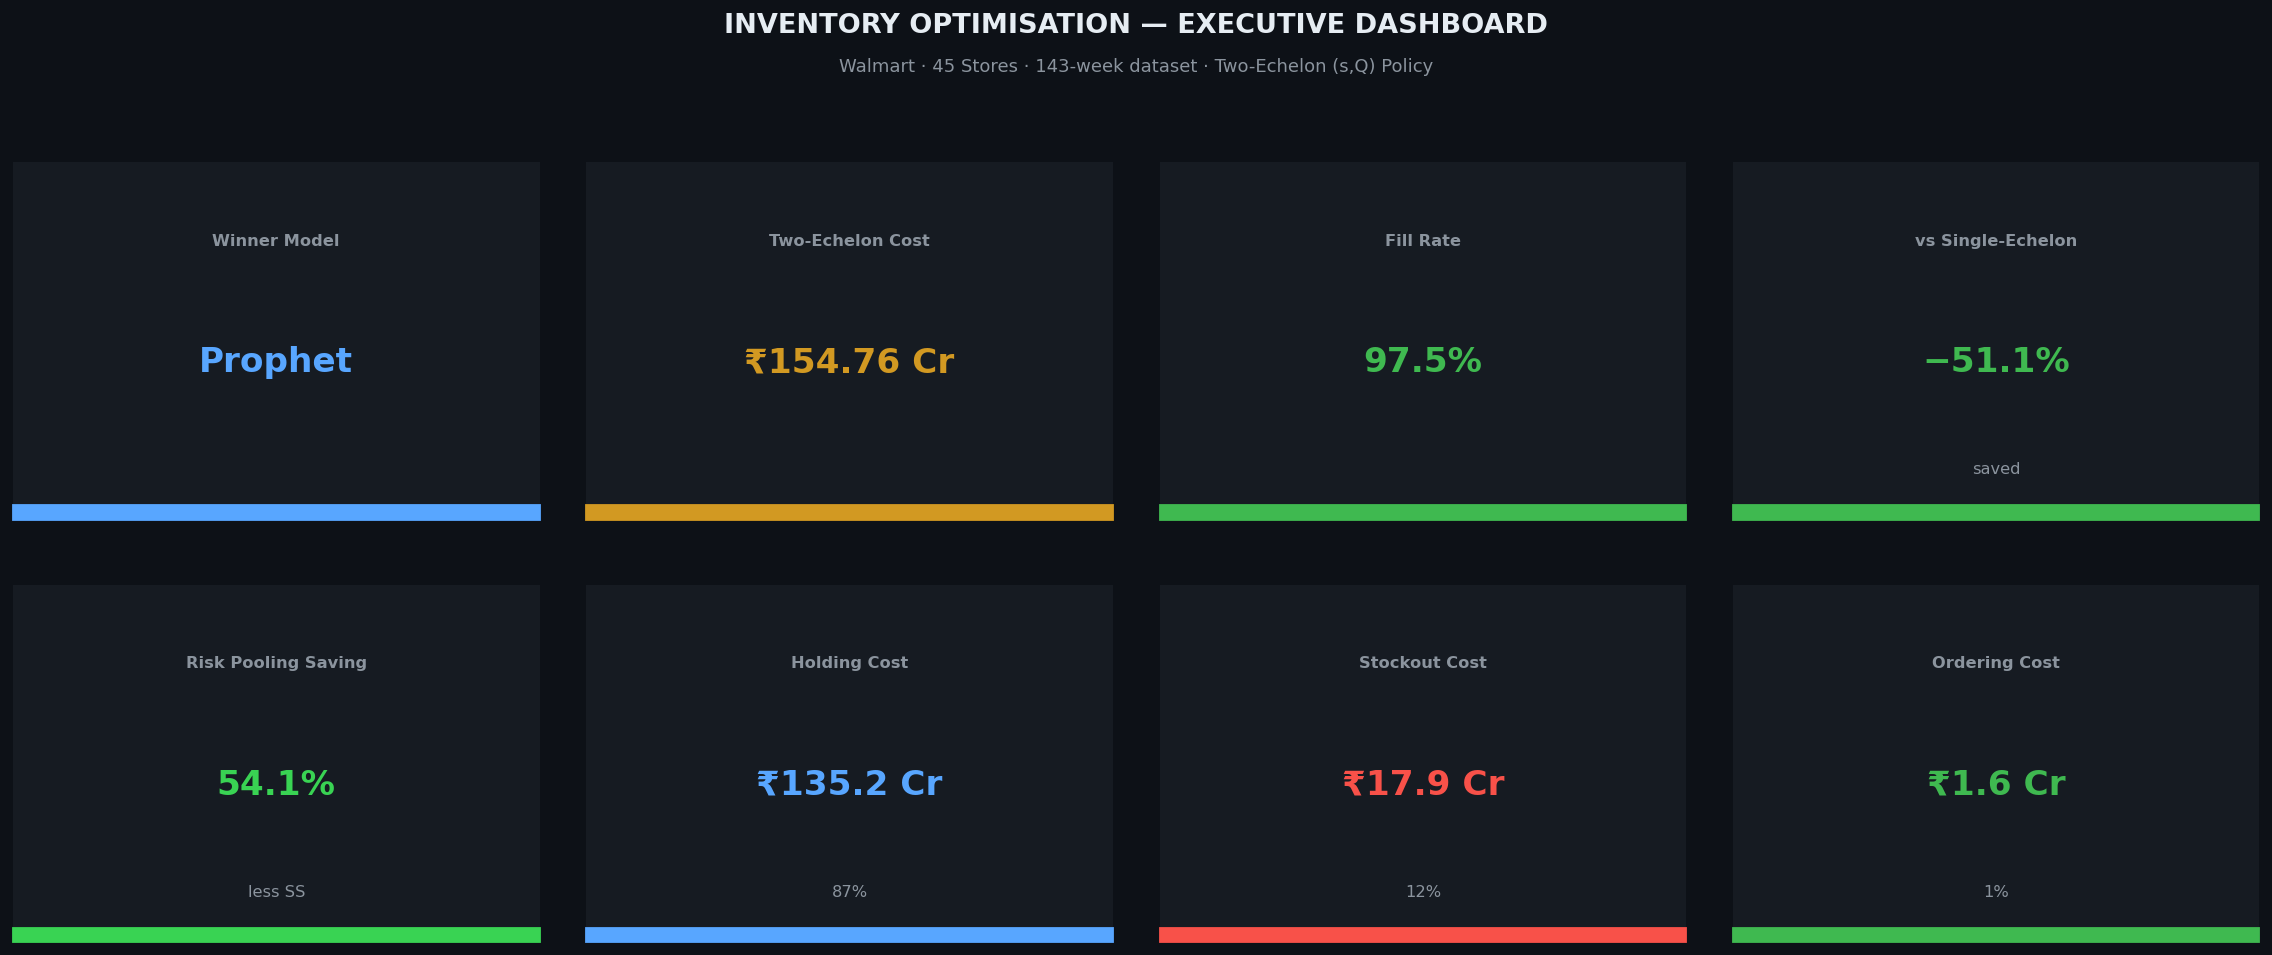

In [26]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 0 — Executive KPI Dashboard
# ────────────────────────────────────────────────────────────────────────
r_w = all_res[winner_name]
b_w = bests[winner_name]
saving = se_cost - r_w["total_cost"]

kpis = [
    ("Winner Model",         winner_name,              ""),
    ("Two-Echelon Cost",     f"₹{r_w['total_cost']/1e7:.2f} Cr",  ""),
    ("Fill Rate",            f"{r_w['fill_rate']:.1%}",            ""),
    ("vs Single-Echelon",    f"−{saving/se_cost*100:.1f}%",        "saved"),
    ("Risk Pooling Saving",  f"{pooling_saving_pct:.1f}%",         "less SS"),
    ("Holding Cost",         f"₹{r_w['hc']/1e7:.1f} Cr",          f"{r_w['hc']/r_w['total_cost']:.0%}"),
    ("Stockout Cost",        f"₹{r_w['sc']/1e7:.1f} Cr",          f"{r_w['sc']/r_w['total_cost']:.0%}"),
    ("Ordering Cost",        f"₹{r_w['oc']/1e7:.1f} Cr",          f"{r_w['oc']/r_w['total_cost']:.0%}"),
]

accent_cols = [ACCENT, ORANGE, GREEN, GREEN,
               TEAL, PALETTE["HC"], PALETTE["SC"], PALETTE["OC"]]

fig = plt.figure(figsize=(18, 5), facecolor=DARK_BG)
fig.text(0.5, 1.0, "INVENTORY OPTIMISATION — EXECUTIVE DASHBOARD",
         ha="center", va="top", fontsize=15, fontweight="bold",
         color=TEXT_COL, transform=fig.transFigure)
fig.text(0.5, 0.93, f"Walmart · 45 Stores · {n_weeks}-week dataset · Two-Echelon (s,Q) Policy",
         ha="center", va="top", fontsize=10, color=MUTED, transform=fig.transFigure)

cols   = 4
rows   = 2
gap_x  = 0.02
gap_y  = 0.10
w      = (1 - gap_x*(cols+1)) / cols
h      = 0.55

for idx, (title, value, sub) in enumerate(kpis):
    col = idx % cols
    row = idx // cols
    x   = gap_x + col*(w+gap_x)
    y   = 0.22 - row*(h+gap_y)
    ax  = fig.add_axes([x, y, w, h])
    ax.set_facecolor(CARD_BG)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

    col_accent = accent_cols[idx]
    ax.add_patch(mpatches.FancyBboxPatch((0,0), 1, 0.04,
        boxstyle="square,pad=0", transform=ax.transAxes,
        color=col_accent, clip_on=False, zorder=5))

    ax.text(0.5, 0.78, title, ha="center", va="center",
            transform=ax.transAxes, fontsize=9, color=MUTED, fontweight="bold")
    ax.text(0.5, 0.44, value, ha="center", va="center",
            transform=ax.transAxes, fontsize=19, color=col_accent, fontweight="bold")
    if sub:
        ax.text(0.5, 0.14, sub, ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color=MUTED)

plt.savefig("fig0_dashboard.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()


### Figure 1 · Demand Forecast Comparison — All Three Models vs Actuals

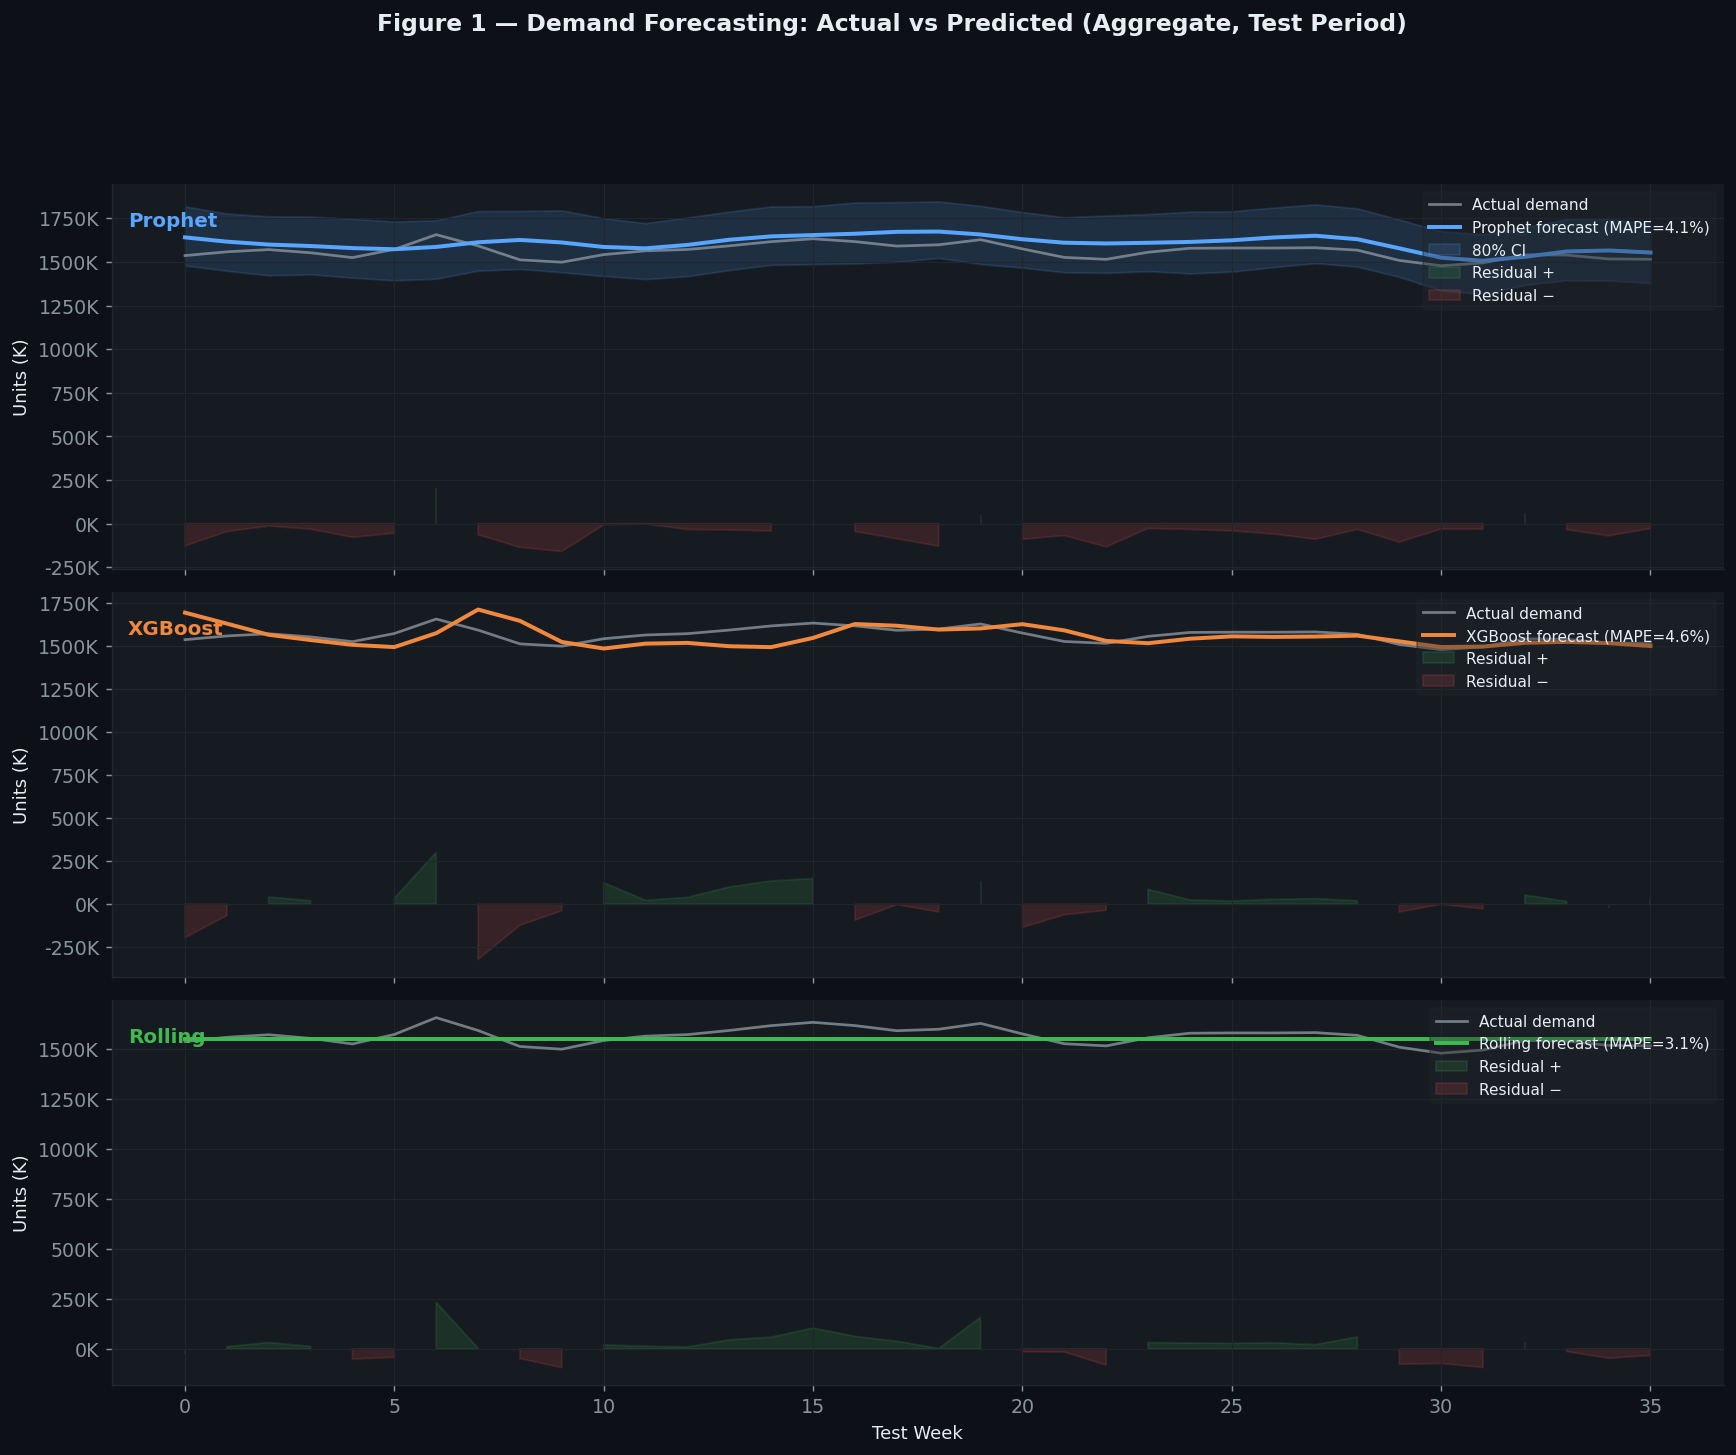

In [27]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Demand Forecast Comparison
# ────────────────────────────────────────────────────────────────────────
test_wks = np.arange(len(actual_agg))
min_len  = min(len(actual_agg), len(mu_x_agg))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True, facecolor=DARK_BG,
                          gridspec_kw={"hspace":0.06})
fig.suptitle("Figure 1 — Demand Forecasting: Actual vs Predicted (Aggregate, Test Period)",
             fontsize=13, fontweight="bold", color=TEXT_COL, y=0.99)

forecasts = [
    ("Prophet", mu_p_agg[:len(actual_agg)], PALETTE["Prophet"],
     mu_p_lower[:len(actual_agg)], mu_p_upper[:len(actual_agg)]),
    ("XGBoost", mu_x_agg[:min_len], PALETTE["XGBoost"], None, None),
    ("Rolling", mu_r_agg[:len(actual_agg)], PALETTE["Rolling"], None, None),
]

for ax, (name, fc, col, lo, hi) in zip(axes, forecasts):
    ax.set_facecolor(CARD_BG)
    n = min(len(actual_agg), len(fc))
    act_s = gaussian_filter1d(actual_agg[:n].astype(float), sigma=0.8)
    fc_s  = gaussian_filter1d(fc[:n].astype(float), sigma=0.8)
    mape  = np.mean(np.abs(actual_agg[:n]-fc[:n])/np.clip(actual_agg[:n],1,None))*100

    ax.plot(test_wks[:n], act_s/1e3, color=MUTED, lw=1.5,
            alpha=0.8, label="Actual demand", zorder=3)
    ax.plot(test_wks[:n], fc_s/1e3, color=col, lw=2.2,
            label=f"{name} forecast (MAPE={mape:.1f}%)", zorder=4)
    if lo is not None and hi is not None:
        ax.fill_between(test_wks[:n], lo[:n]/1e3, hi[:n]/1e3,
                        color=col, alpha=0.15, label="80% CI")
    # residuals as bottom strip
    res = (actual_agg[:n]-fc[:n])/1e3
    ax.fill_between(test_wks[:n], res, 0,
                    where=res>0, color=GREEN,  alpha=0.15, label="Residual +")
    ax.fill_between(test_wks[:n], res, 0,
                    where=res<0, color=RED,    alpha=0.15, label="Residual −")

    ax.set_ylabel("Units (K)", color=TEXT_COL)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.0f}K"))
    ax.legend(loc="upper right", fontsize=8.5, framealpha=0.4)
    ax.text(0.01, 0.93, name, transform=ax.transAxes,
            fontsize=11, fontweight="bold", color=col, va="top")
    ax.spines["bottom"].set_color(GRID_COL)
    ax.spines["left"].set_color(GRID_COL)

axes[-1].set_xlabel("Test Week", color=TEXT_COL)
plt.savefig("fig1_forecast.png")
plt.show()


### Figure 2 · System Architecture

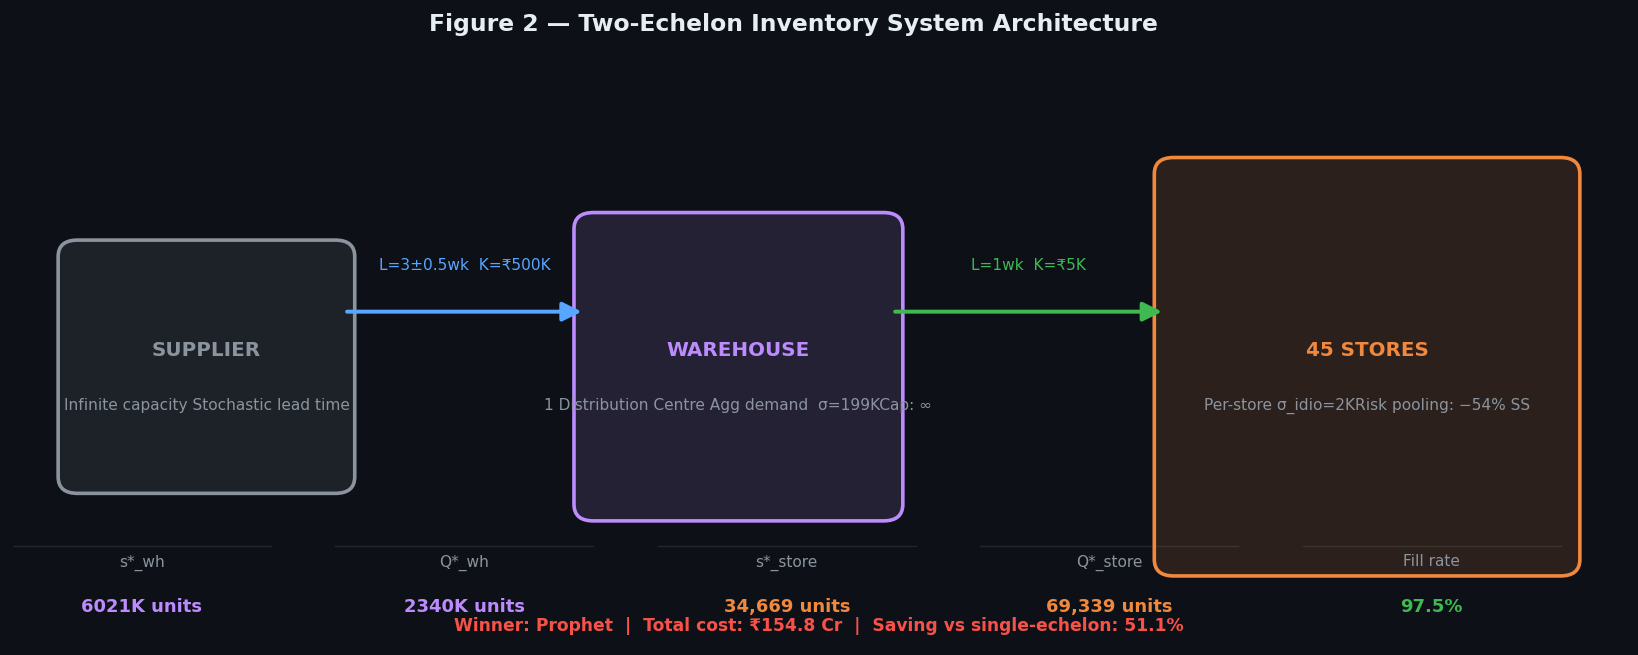

In [28]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 2 — System Architecture (polished flow diagram)
# ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5.5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 4)

fig.suptitle("Figure 2 — Two-Echelon Inventory System Architecture",
             fontsize=13, fontweight="bold", color=TEXT_COL, y=0.99)

def rounded_box(ax, x, y, w, h, label, sublabel, color, lw=2):
    box = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.12", linewidth=lw,
        edgecolor=color, facecolor=color+"22", zorder=3)
    ax.add_patch(box)
    ax.text(x, y+0.12, label, ha="center", va="center",
            fontsize=11, fontweight="bold", color=color, zorder=5)
    if sublabel:
        ax.text(x, y-0.28, sublabel, ha="center", va="center",
                fontsize=8.5, color=MUTED, zorder=5)

def flow_arrow(ax, x1, x2, y, color, label, label_y_off=0.28):
    ax.annotate("",
        xy=(x2-0.05, y), xytext=(x1+0.05, y),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2,
                        mutation_scale=22))
    ax.text((x1+x2)/2, y+label_y_off, label,
            ha="center", va="bottom", fontsize=8.5, color=color)

# nodes
rounded_box(ax, 1.2, 2.0, 1.6, 1.6,
            "SUPPLIER", "Infinite capacity Stochastic lead time",
            "#8B949E")
rounded_box(ax, 4.5, 2.0, 1.8, 2.0,
            "WAREHOUSE",f"1 Distribution Centre Agg demand  σ={sigma_aggregate/1e3:.0f}K"
            f"Cap: {'∞' if WH_CAPACITY==np.inf else f'{WH_CAPACITY/1e3:.0f}K'}",
            PALETTE["WH"])
rounded_box(ax, 8.4, 2.0, 2.4, 2.8,
            "45 STORES",
            f"Per-store σ_idio={np.mean(list(store_sigma_idio.values()))/1e3:.0f}K"
            f"Risk pooling: −{pooling_saving_pct:.0f}% SS",
            PALETTE["Store"])

# arrows
flow_arrow(ax, 2.0, 3.6, 2.4,
           "#58A6FF",
           f"L={CFG.l_wh}±{CFG.l_wh_std}wk  K=₹{CFG.order_cost_wh/1e3:.0f}K")
flow_arrow(ax, 5.4, 7.2, 2.4,
           PALETTE["OC"],
           f"L={CFG.l_store}wk  K=₹{CFG.order_cost_store/1e3:.0f}K")

# metrics bar
for i, (label, val, col) in enumerate([
    (f"s*_wh",    f"{bests[winner_name]['s_wh']/1e3:.0f}K units",    PALETTE["WH"]),
    (f"Q*_wh",    f"{bests[winner_name]['Q_wh']/1e3:.0f}K units",    PALETTE["WH"]),
    (f"s*_store", f"{bests[winner_name]['s_store']:,} units",         PALETTE["Store"]),
    (f"Q*_store", f"{bests[winner_name]['Q_store']:,} units",         PALETTE["Store"]),
    (f"Fill rate",f"{all_res[winner_name]['fill_rate']:.1%}",         GREEN),
]):
    xi = 0.8 + i*2.0
    ax.text(xi, 0.55, label, ha="center", fontsize=8.5, color=MUTED)
    ax.text(xi, 0.22, val,   ha="center", fontsize=10,  color=col, fontweight="bold")
    ax.plot([xi-0.8, xi+0.8],[0.7,0.7], color=GRID_COL, lw=0.8)

ax.text(5.0, 0.08, f"Winner: {winner_name}  |  Total cost: ₹{all_res[winner_name]['total_cost']/1e7:.1f} Cr  "
        f"|  Saving vs single-echelon: {(se_cost-all_res[winner_name]['total_cost'])/se_cost*100:.1f}%",
        ha="center", fontsize=9.5, color=RED, fontweight="bold")

plt.savefig("fig3_risk_pooling.png")
plt.show()


### Figure 3 · Risk Pooling Deep Dive

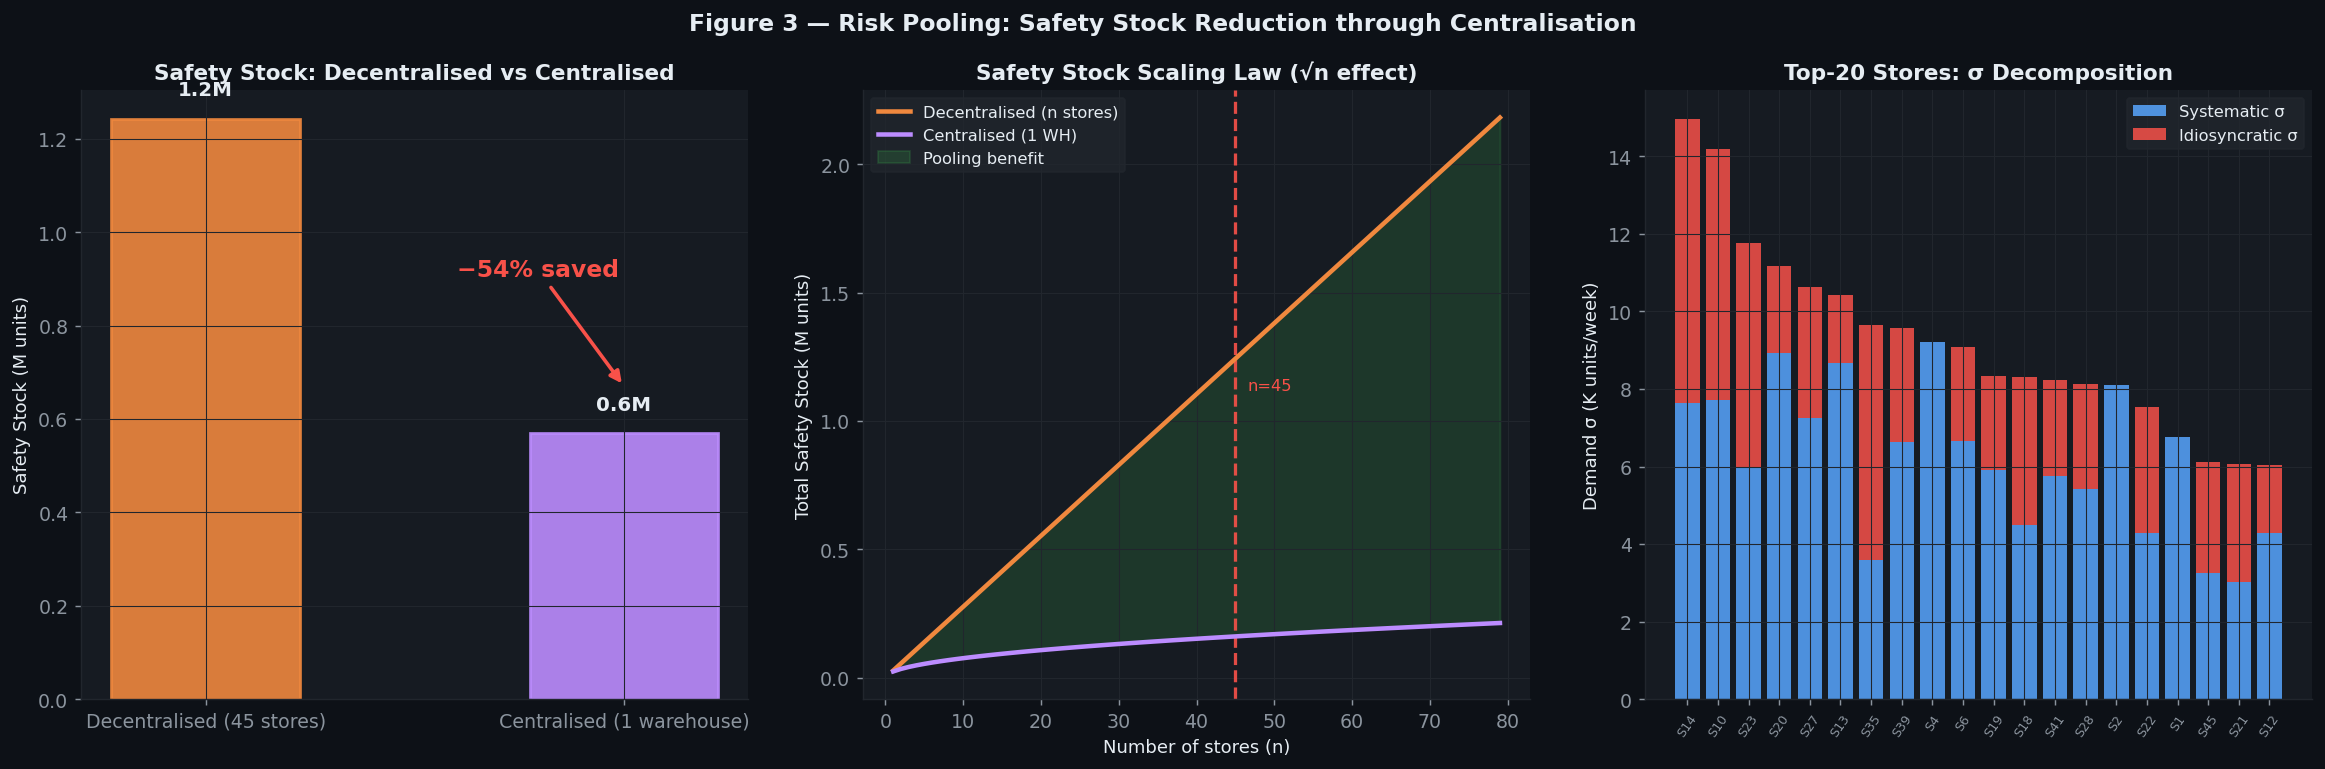

In [29]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Risk Pooling Deep Dive
# ────────────────────────────────────────────────────────────────────────
import os
os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=DARK_BG)
fig.suptitle("Figure 3 — Risk Pooling: Safety Stock Reduction through Centralisation",
             fontsize=13, fontweight="bold", color=TEXT_COL)

# Panel A — bar comparison
ax = axes[0]
ax.set_facecolor(CARD_BG)

vals  = [ss_decentralised/1e6, ss_centralised/1e6]
lbls  = ["Decentralised (45 stores)", "Centralised (1 warehouse)"]
cols  = [PALETTE["Store"], PALETTE["WH"]]

bars = ax.bar(lbls, vals, color=cols, width=0.45, alpha=0.9,
              linewidth=1.5, edgecolor=[c+"88" for c in cols])

for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05,
            f"{v:.1f}M", ha="center", fontsize=11,
            fontweight="bold", color=TEXT_COL)

# FIXED LINE (separate statement)
ax.annotate(f"−{pooling_saving_pct:.0f}% saved",
            xy=(1, vals[1]+0.1),
            xytext=(0.6, (vals[0]+vals[1])/2),
            fontsize=13, color=RED, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=RED, lw=2))

ax.set_ylabel("Safety Stock (M units)")
ax.set_title("Safety Stock: Decentralised vs Centralised")
ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)


# Panel B — scaling curve
ax = axes[1]
ax.set_facecolor(CARD_BG)

ratios = np.arange(1, 80)
ss_dec = ratios * CFG.z_alpha * sigma_per_store_avg * np.sqrt(CFG.l_total)
ss_cen = CFG.z_alpha * (sigma_per_store_avg*np.sqrt(ratios)) * np.sqrt(CFG.l_wh)

ax.plot(ratios, ss_dec/1e6, color=PALETTE["Store"], lw=2.5,
        label="Decentralised (n stores)", zorder=4)
ax.plot(ratios, ss_cen/1e6, color=PALETTE["WH"], lw=2.5,
        label="Centralised (1 WH)", zorder=4)

ax.fill_between(ratios, ss_cen/1e6, ss_dec/1e6,
                alpha=0.18, color=GREEN, label="Pooling benefit")

ax.axvline(n_stores, color=RED, ls="--", lw=1.8, alpha=0.9)
ax.text(n_stores+1.5, ss_dec[n_stores-1]/1e6*0.9,
        f"n={n_stores}", color=RED, fontsize=9)

ax.set_xlabel("Number of stores (n)")
ax.set_ylabel("Total Safety Stock (M units)")
ax.set_title("Safety Stock Scaling Law (√n effect)")
ax.legend(fontsize=9)

ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)


# Panel C — σ decomposition
ax = axes[2]
ax.set_facecolor(CARD_BG)

sys_v = np.array([store_shares[s]*sigma_aggregate for s in store_ids])
idy_v = np.array([store_sigma_idio[s] for s in store_ids])

idx_s = np.argsort(sys_v + idy_v)[::-1][:20]
xs = np.arange(len(idx_s))

ax.bar(xs, sys_v[idx_s]/1e3, label="Systematic σ",
       color=PALETTE["HC"], alpha=0.85)

ax.bar(xs, idy_v[idx_s]/1e3,
       bottom=sys_v[idx_s]/1e3,
       label="Idiosyncratic σ",
       color=PALETTE["SC"], alpha=0.85)

ax.set_xticks(xs)
ax.set_xticklabels([f"S{store_ids[i]}" for i in idx_s],
                   rotation=55, fontsize=7)

ax.set_ylabel("Demand σ (K units/week)")
ax.set_title("Top-20 Stores: σ Decomposition")
ax.legend(fontsize=9)

ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)


fig.tight_layout()

# SAFE SAVE PATH
plt.savefig("outputs/fig3_risk_pooling.png",
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)

plt.show()


### Figure 4 · Two-Echelon Model Comparison (Cost · SL · Breakdown)

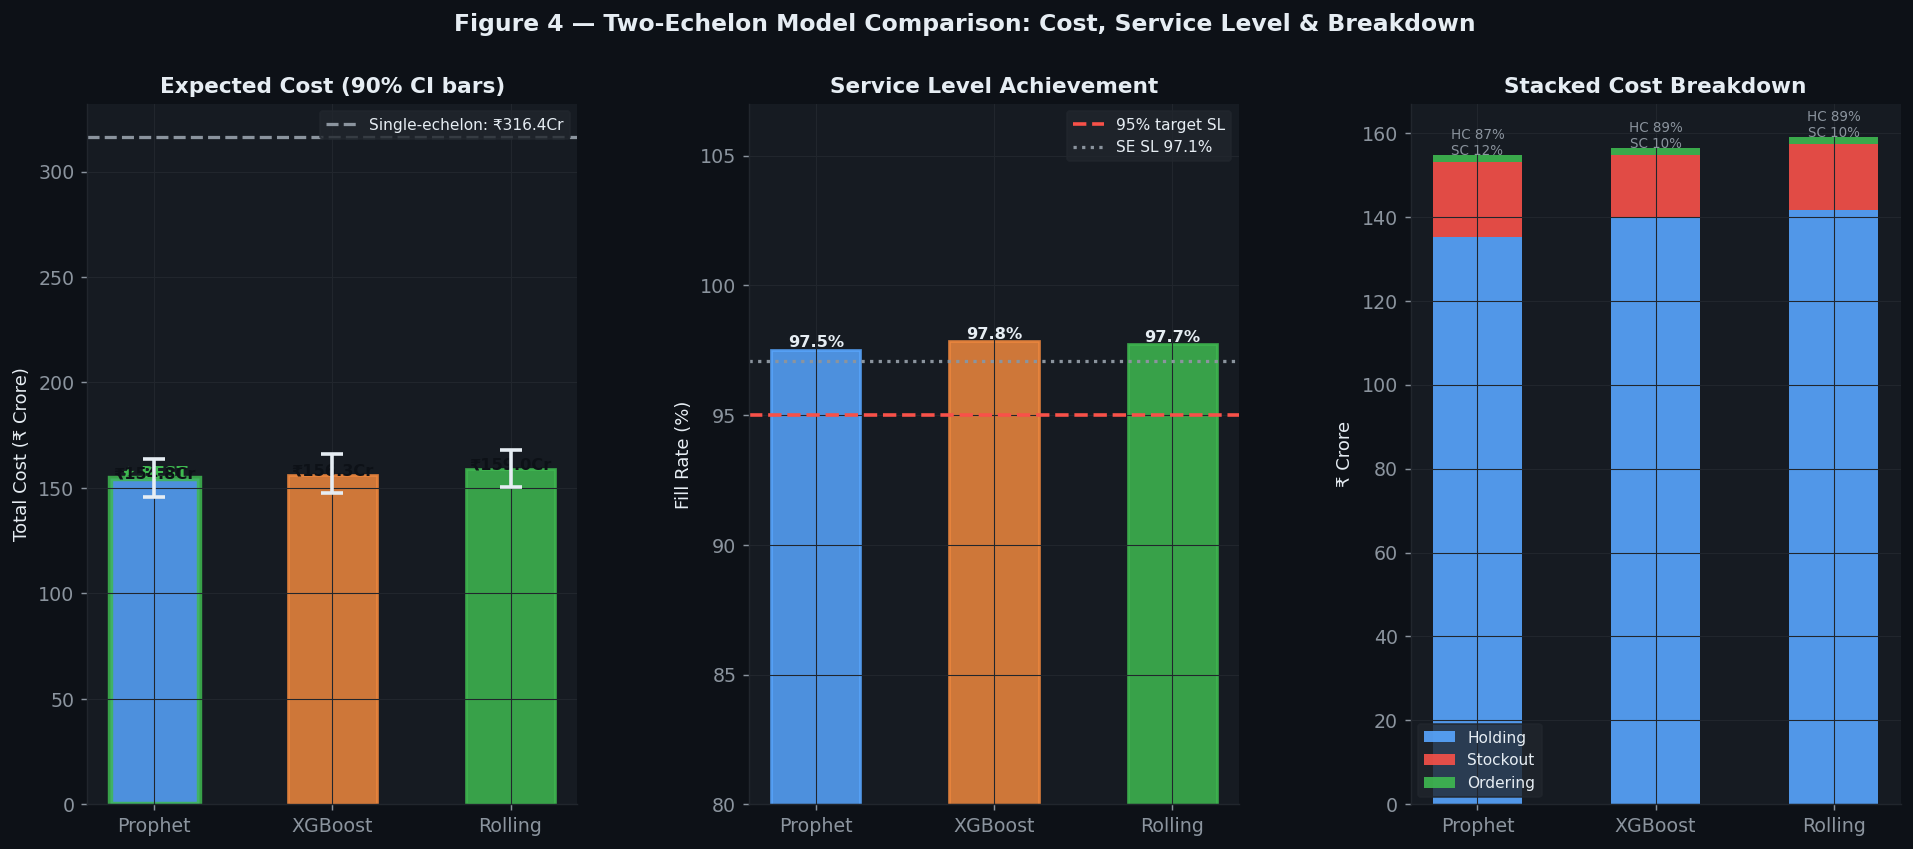

In [30]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 4 — Model Comparison
# ────────────────────────────────────────────────────────────────────────
import os
os.makedirs("outputs", exist_ok=True)

fig = plt.figure(figsize=(18, 7), facecolor=DARK_BG)
fig.suptitle("Figure 4 — Two-Echelon Model Comparison: Cost, Service Level & Breakdown",
             fontsize=13, fontweight="bold", color=TEXT_COL)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel A: total cost with CI error bars ──
ax = fig.add_subplot(gs[0])
ax.set_facecolor(CARD_BG)

costs  = [all_res[m]["total_cost"]/1e7 for m in mnames]
ci_lo  = [np.percentile(all_res[m]["totals_per_run"], 5)/1e7 for m in mnames]
ci_hi  = [np.percentile(all_res[m]["totals_per_run"], 95)/1e7 for m in mnames]

cols = [PALETTE[m] for m in mnames]
xs   = np.arange(len(mnames))

bars = ax.bar(xs, costs, color=cols, width=0.5, alpha=0.85,
              edgecolor=[c+"99" for c in cols], linewidth=1.5)

ax.errorbar(xs, costs,
            yerr=[np.array(costs)-np.array(ci_lo),
                  np.array(ci_hi)-np.array(costs)],
            fmt="none", color=TEXT_COL, capsize=6,
            capthick=2, elinewidth=2, zorder=5)

ax.axhline(se_cost/1e7, color=PALETTE["SE"], ls="--", lw=1.8,
           label=f"Single-echelon: ₹{se_cost/1e7:.1f}Cr")

win_idx = mnames.index(winner_name)
bars[win_idx].set_edgecolor(GREEN)
bars[win_idx].set_linewidth(3)

ax.text(xs[win_idx], costs[win_idx]+0.05,
        "★ BEST", ha="center", color=GREEN,
        fontsize=9, fontweight="bold")

for bar, v in zip(bars, costs):
    ax.text(bar.get_x()+bar.get_width()/2, v-0.15,
            f"₹{v:.1f}Cr", ha="center",
            fontsize=9, color=DARK_BG, fontweight="bold")

ax.set_xticks(xs)
ax.set_xticklabels(mnames)
ax.set_ylabel("Total Cost (₹ Crore)")
ax.set_title("Expected Cost (90% CI bars)")
ax.legend(fontsize=8.5)

ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)


# ── Panel B: fill rate ──
ax = fig.add_subplot(gs[1])
ax.set_facecolor(CARD_BG)

sls = [all_res[m]["fill_rate"]*100 for m in mnames]

bars = ax.bar(xs, sls, color=cols, width=0.5, alpha=0.85,
              edgecolor=[c+"99" for c in cols], linewidth=1.5)

ax.axhline(95, color=RED, ls="--", lw=2, label="95% target SL")
ax.axhline(se_sl*100, color=PALETTE["SE"], ls=":", lw=1.8,
           label=f"SE SL {se_sl:.1%}")

for bar, v in zip(bars, sls):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1,
            f"{v:.1f}%", ha="center",
            fontsize=9, fontweight="bold", color=TEXT_COL)

ax.set_xticks(xs)
ax.set_xticklabels(mnames)
ax.set_ylabel("Fill Rate (%)")
ax.set_ylim(80, 107)
ax.set_title("Service Level Achievement")
ax.legend(fontsize=8.5)

ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)


# ── Panel C: cost breakdown ──
ax = fig.add_subplot(gs[2])
ax.set_facecolor(CARD_BG)

hc_ = np.array([all_res[m]["hc"]/1e7 for m in mnames])
sc_ = np.array([all_res[m]["sc"]/1e7 for m in mnames])
oc_ = np.array([all_res[m]["oc"]/1e7 for m in mnames])

ax.bar(xs, hc_, label="Holding", color=PALETTE["HC"], width=0.5, alpha=0.9)
ax.bar(xs, sc_, bottom=hc_, label="Stockout", color=PALETTE["SC"], width=0.5, alpha=0.9)
ax.bar(xs, oc_, bottom=hc_+sc_, label="Ordering", color=PALETTE["OC"], width=0.5, alpha=0.9)

for i, m in enumerate(mnames):
    tot = hc_[i] + sc_[i] + oc_[i]
    ax.text(xs[i], tot+0.02,
            f"HC {hc_[i]/tot:.0%}\nSC {sc_[i]/tot:.0%}",
            ha="center", fontsize=7.5, color=MUTED)

ax.set_xticks(xs)
ax.set_xticklabels(mnames)
ax.set_ylabel("₹ Crore")
ax.set_title("Stacked Cost Breakdown")
ax.legend(fontsize=8.5)

ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)


# SAVE (fixed path)
plt.savefig("outputs/fig4_model_comparison.png",
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)

plt.show()

### Figure 5 · Warehouse Inventory Trajectories — All Models

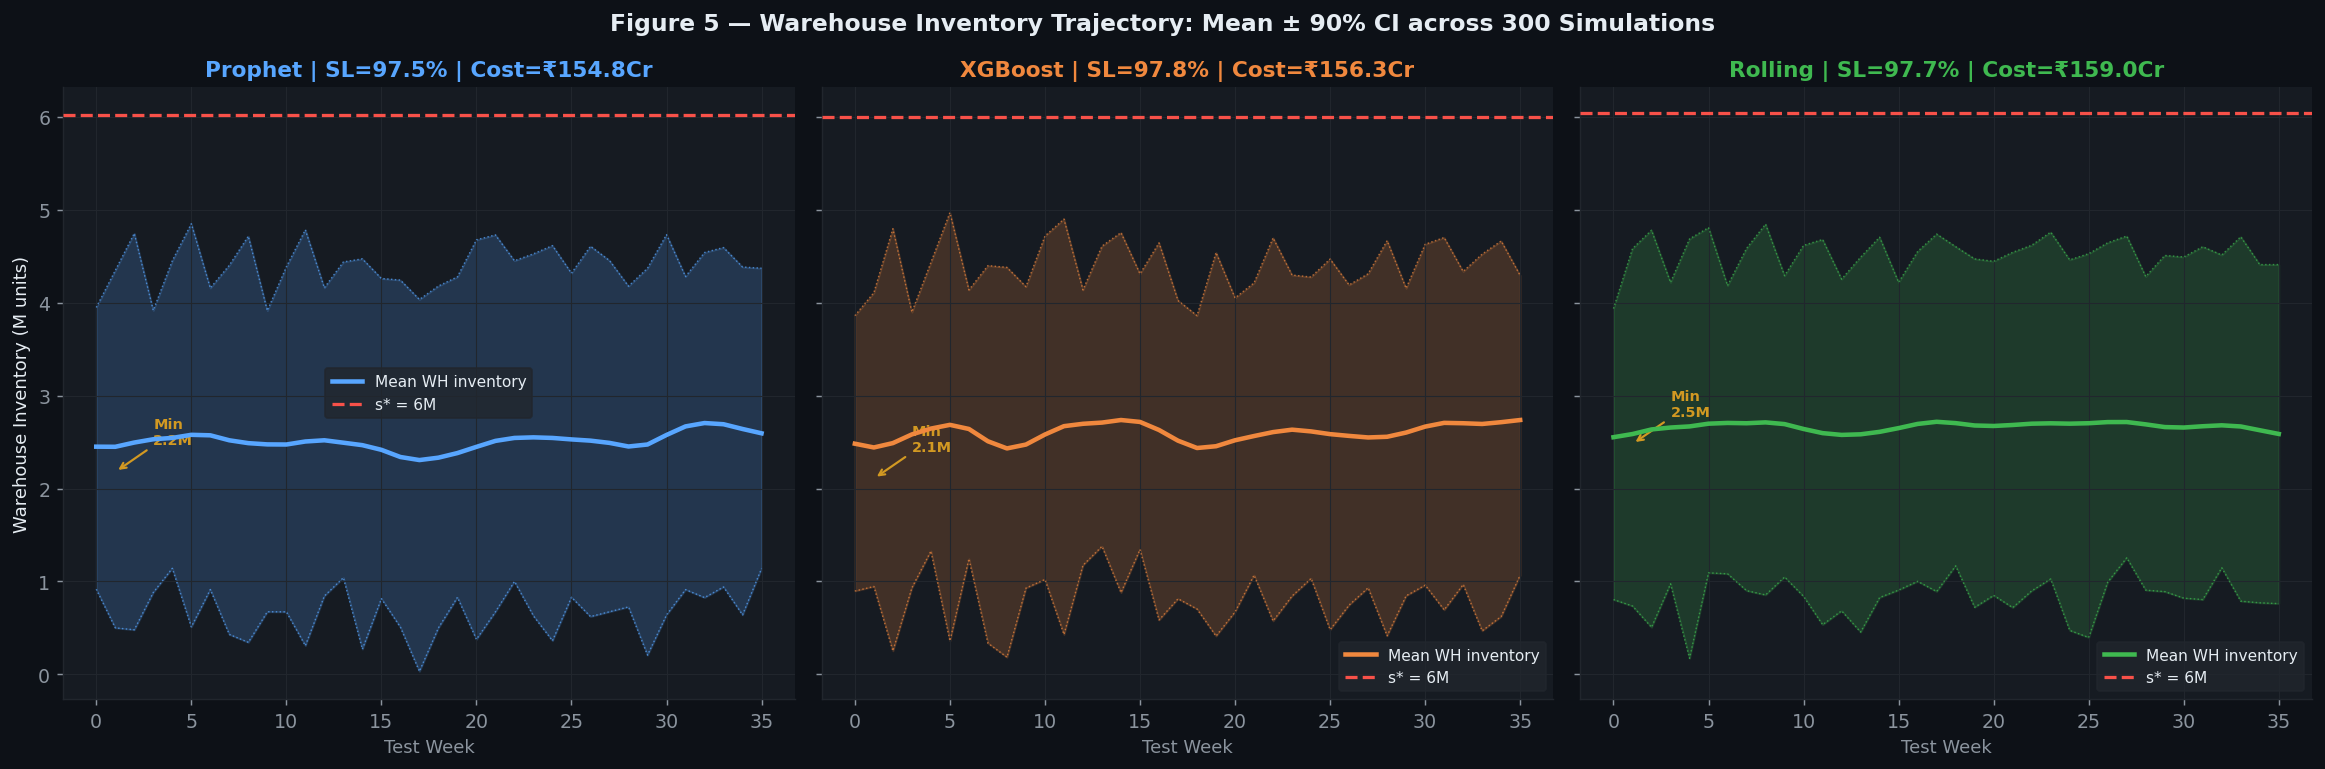

In [31]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 5 — Warehouse Inventory Trajectory
# ────────────────────────────────────────────────────────────────────────
import os
os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         facecolor=DARK_BG, sharey=True)

fig.suptitle("Figure 5 — Warehouse Inventory Trajectory: Mean ± 90% CI across 300 Simulations",
             fontsize=13, fontweight="bold", color=TEXT_COL)

for ax, mname in zip(axes, mnames):
    ax.set_facecolor(CARD_BG)

    r   = all_res[mname]
    col = PALETTE[mname]
    wks = np.arange(len(r["wh_inv_mean"]))

    # uncertainty band
    ax.fill_between(wks,
                    r["wh_inv_p5"]/1e6,
                    r["wh_inv_p95"]/1e6,
                    alpha=0.2, color=col)

    # smooth mean
    smooth_mean = gaussian_filter1d(r["wh_inv_mean"], sigma=1.2)

    ax.plot(wks, smooth_mean/1e6,
            color=col, lw=2.5,
            label="Mean WH inventory", zorder=4)

    ax.plot(wks, r["wh_inv_p5"]/1e6,
            color=col, lw=0.8, ls=":", alpha=0.7)

    ax.plot(wks, r["wh_inv_p95"]/1e6,
            color=col, lw=0.8, ls=":", alpha=0.7)

    # reorder point
    ax.axhline(bests[mname]["s_wh"]/1e6,
               color=RED, ls="--", lw=1.8,
               zorder=5,
               label=f"s* = {bests[mname]['s_wh']/1e6:.0f}M")

    # min annotation (cleaned)
    min_wk = int(np.argmin(r["wh_inv_mean"]))
    min_val = r["wh_inv_mean"][min_wk]/1e6

    ax.annotate(f"Min\n{min_val:.1f}M",
                xy=(min_wk, min_val),
                xytext=(min_wk+2, min_val+0.3),
                fontsize=8, color=ORANGE, fontweight="bold",
                arrowprops=dict(arrowstyle="->",
                                color=ORANGE, lw=1.2))

    ax.set_title(
        f"{mname} | SL={r['fill_rate']:.1%} | Cost=₹{r['total_cost']/1e7:.1f}Cr",
        color=col
    )

    ax.set_xlabel("Test Week", color=MUTED)
    ax.legend(fontsize=8.5)

    ax.spines["bottom"].set_color(GRID_COL)
    ax.spines["left"].set_color(GRID_COL)

axes[0].set_ylabel("Warehouse Inventory (M units)")

fig.tight_layout()

# SAFE SAVE
plt.savefig("outputs/fig5_wh_trajectory.png",
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)

plt.show()


### Figure 6 · Monte Carlo Cost Distribution — Histogram + KDE

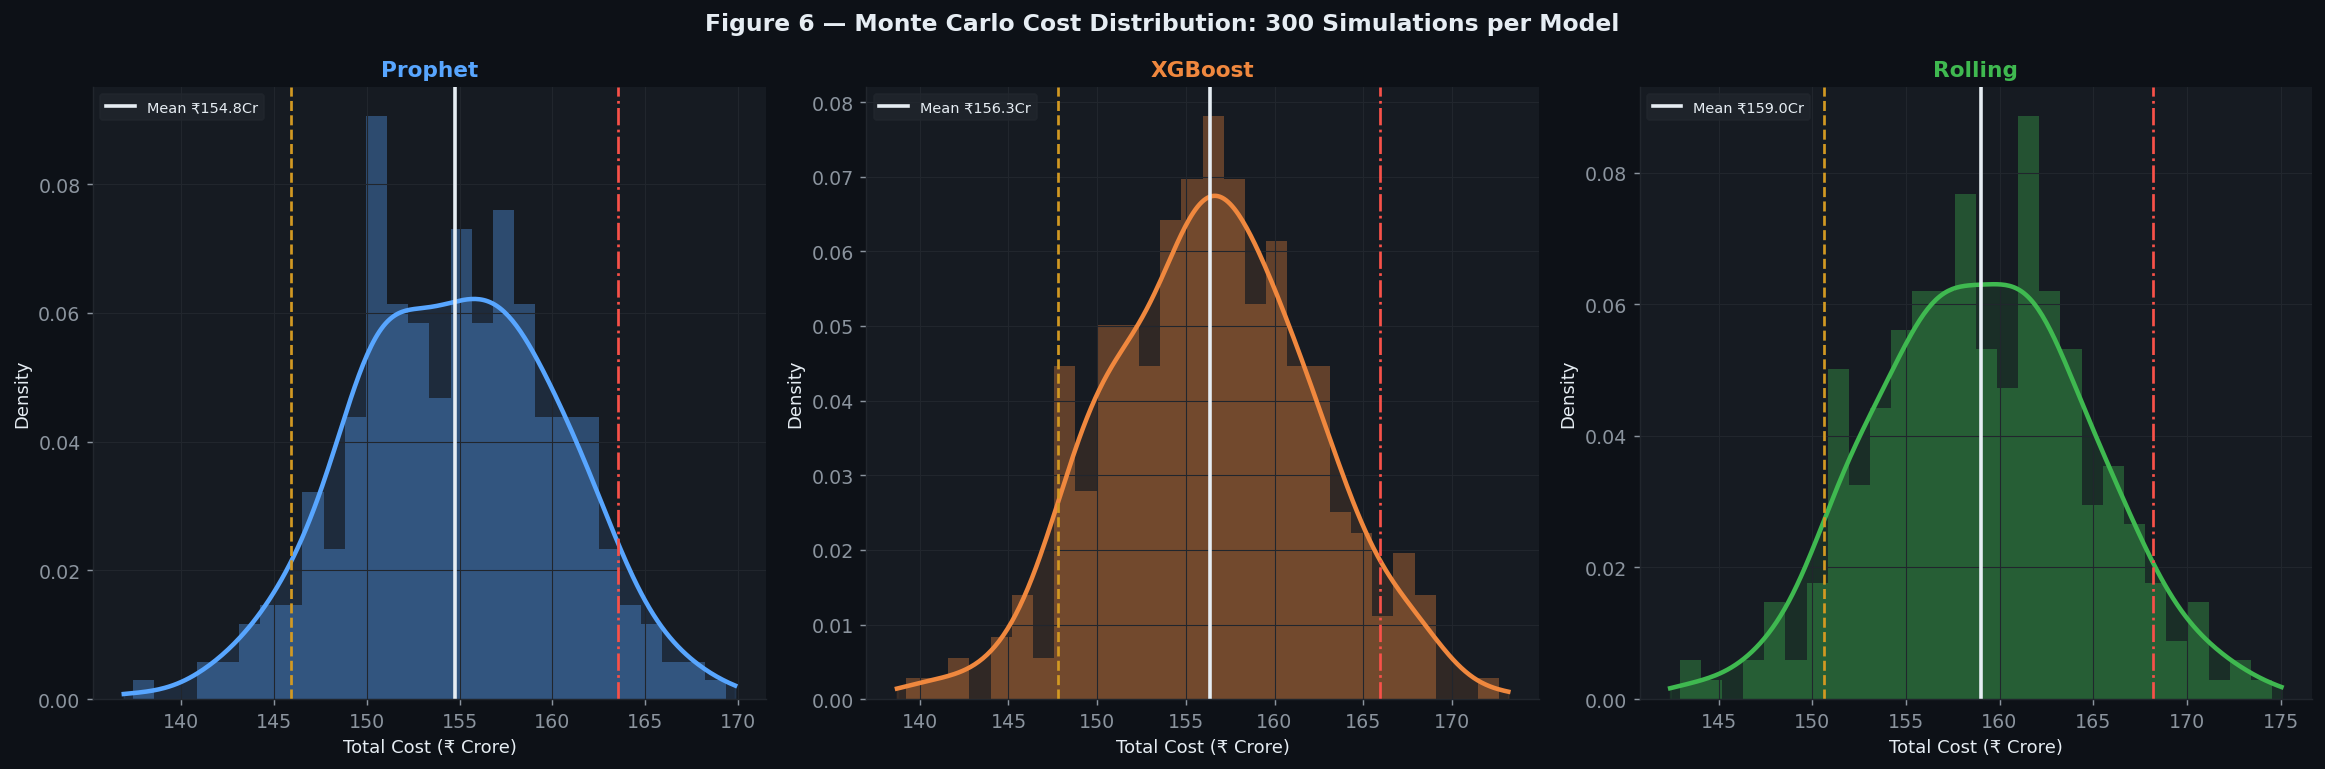

In [32]:
import os
os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=DARK_BG)
fig.suptitle("Figure 6 — Monte Carlo Cost Distribution: 300 Simulations per Model",
             fontsize=13, fontweight="bold", color=TEXT_COL)

for ax, mname in zip(axes, mnames):
    ax.set_facecolor(CARD_BG)

    runs = np.array(all_res[mname]["totals_per_run"]) / 1e7

    if len(runs) == 0:
        print(f"⚠️ No data for {mname}")
        continue

    col = PALETTE[mname]

    # KDE safe check
    if np.std(runs) > 0:
        kde = sp_stats.gaussian_kde(runs, bw_method=0.35)
        xs = np.linspace(runs.min()-0.5, runs.max()+0.5, 300)
        ax.plot(xs, kde(xs), color=col, lw=2.5)
        ax.fill_between(xs, kde(xs), alpha=0.12, color=col)

    ax.hist(runs, bins=28, density=True, color=col, alpha=0.35)

    mean_v = runs.mean()
    p5_v = np.percentile(runs, 5)
    p95_v = np.percentile(runs, 95)

    ax.axvline(mean_v, color=TEXT_COL, lw=2, label=f"Mean ₹{mean_v:.1f}Cr")
    ax.axvline(p5_v, color=ORANGE, lw=1.5, ls="--")
    ax.axvline(p95_v, color=RED, lw=1.5, ls="-.")

    ax.set_title(mname, color=col)
    ax.set_xlabel("Total Cost (₹ Crore)")
    ax.set_ylabel("Density")

    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/fig6_monte_carlo.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

### Figure 7 · Cost vs Service Level Pareto Frontier

Building Pareto frontier (quick scan) …


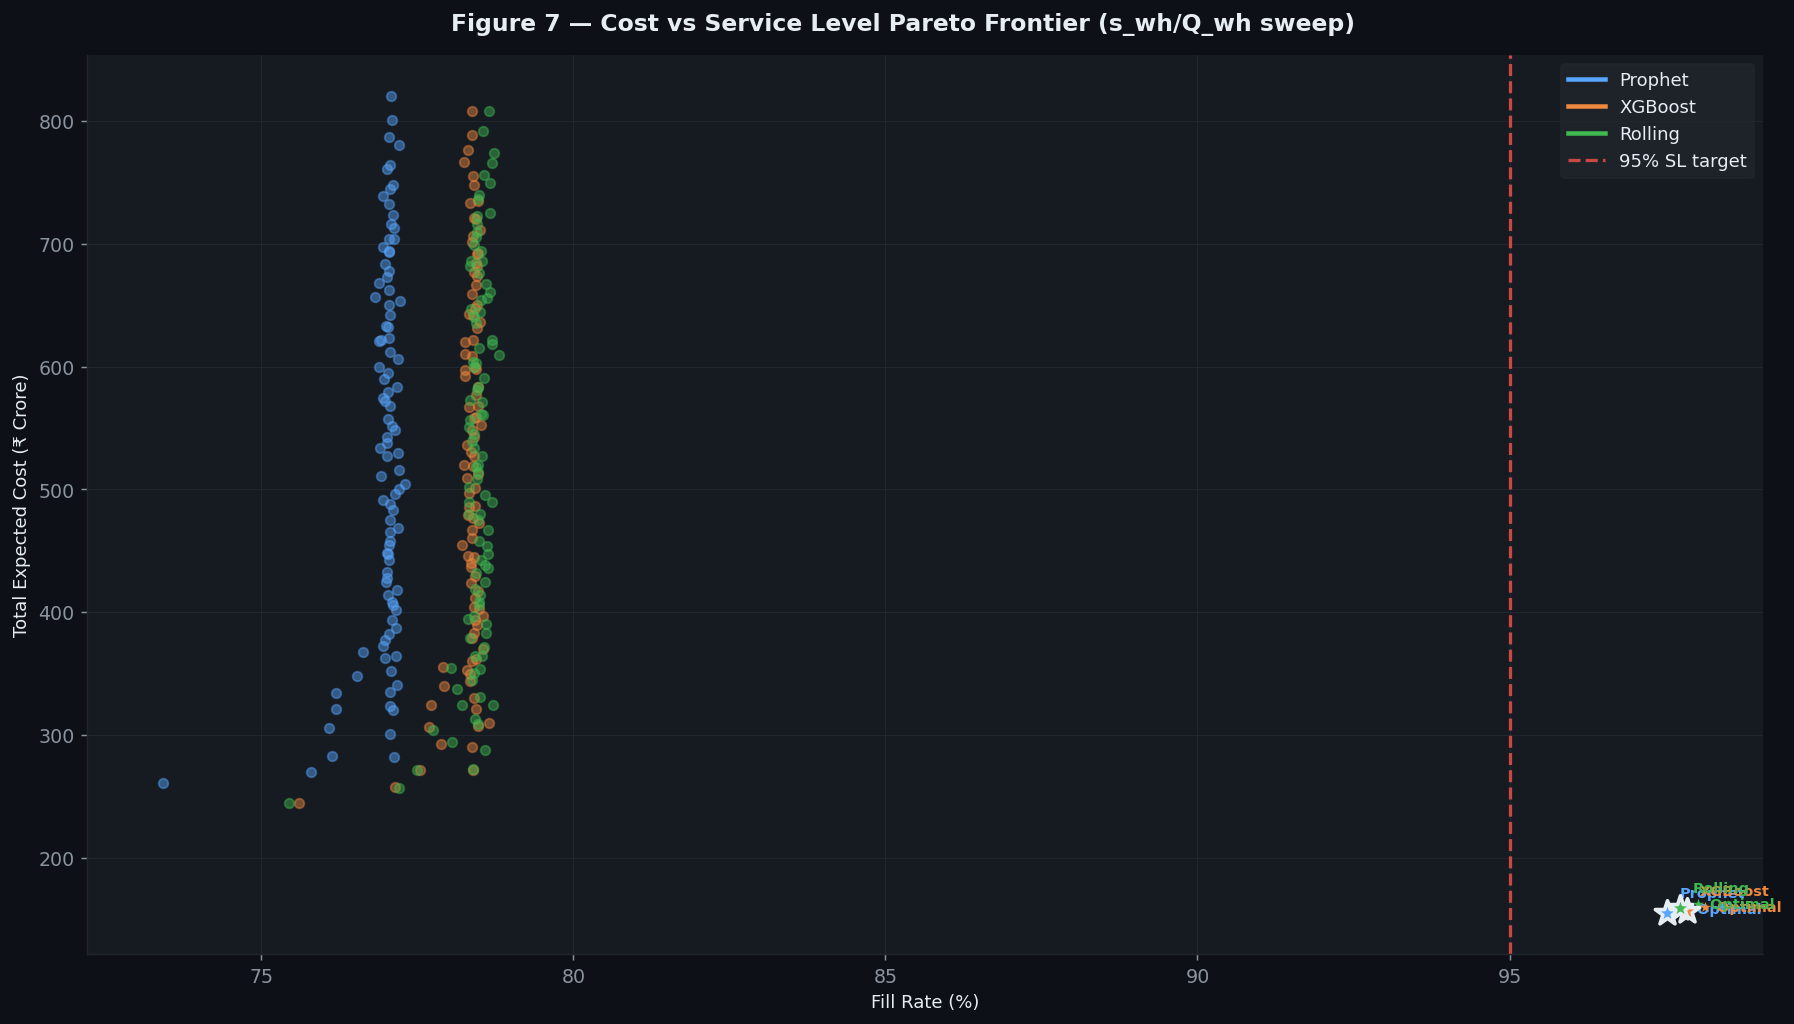

In [33]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 7 — Cost vs SL Pareto Frontier (FINAL CLEAN)
# ────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)

print("Building Pareto frontier (quick scan) …")

def quick_sim(s_wh_factor, Q_wh_factor, sigma_agg, mu_full, n_sims=40):
    rop_n = avg_demand_agg * CFG.l_wh
    ss_wh = CFG.z_alpha * np.sqrt(
        CFG.l_wh * sigma_agg**2 +
        avg_demand_agg**2 * CFG.l_wh_std**2
    )

    rop_c = rop_n + ss_wh
    s_wh  = int(rop_c * s_wh_factor)
    Q_wh  = int(avg_demand_agg * CFG.l_wh * Q_wh_factor)

    avg_d = avg_demand_agg / n_stores
    rop_s = avg_d * CFG.l_store
    s_st  = int(rop_s * 1.5)
    Q_st  = int(avg_d * 1.0)

    r = _run_sim(s_wh, Q_wh, s_st, Q_st, mu_full, sigma_agg, n_sims)

    return r["total_cost"]/1e7, r["fill_rate"]*100


# parameter sweep
s_factors = np.linspace(0.6, 3.5, 12)
Q_factors = np.linspace(0.4, 2.5, 8)

pareto = {"Prophet": [], "XGBoost": [], "Rolling": []}

cfg_list = [
    ("Prophet", mu_p_agg_full, sigma_p_agg),
    ("XGBoost", mu_x_agg_full, sigma_x_agg),
    ("Rolling", mu_r_agg_full, sigma_r_agg),
]

# generate points
for sf in s_factors:
    for qf in Q_factors:
        for mname, mu, sig in cfg_list:
            try:
                cost, sl = quick_sim(sf, qf, sig, mu)
                pareto[mname].append((sl, cost))   # NOTE: (SL, Cost)
            except Exception as e:
                print(f"⚠️ Skipped {mname}: {e}")


# ── plotting ──
fig, ax = plt.subplots(figsize=(14, 8), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

fig.suptitle("Figure 7 — Cost vs Service Level Pareto Frontier (s_wh/Q_wh sweep)",
             fontsize=13, fontweight="bold", color=TEXT_COL)

for mname in mnames:
    pts = np.array(pareto[mname])

    if len(pts) == 0:
        print(f"⚠️ No Pareto data for {mname}")
        continue

    col = PALETTE[mname]

    # scatter
    ax.scatter(pts[:,0], pts[:,1], color=col,
               s=28, alpha=0.45, zorder=3)

    # Pareto front (sorted + cumulative min)
    df_p = pd.DataFrame(pts, columns=["SL", "Cost"]).sort_values("SL")
    df_p["min_cost"] = df_p["Cost"].cummin()
    front = df_p[df_p["Cost"] == df_p["min_cost"]]

    ax.plot(front["SL"], front["Cost"],
            color=col, lw=2.5, label=mname, zorder=4)


# mark optimal points
for mname in mnames:
    sl_opt = all_res[mname]["fill_rate"] * 100
    c_opt  = all_res[mname]["total_cost"] / 1e7

    ax.scatter(sl_opt, c_opt,
               s=200, color=PALETTE[mname],
               edgecolors=TEXT_COL, linewidths=2,
               marker="*", zorder=6)

    ax.text(sl_opt + 0.2, c_opt + 0.05,
            f"{mname}\n★ Optimal",
            fontsize=8, color=PALETTE[mname],
            fontweight="bold")


# styling
ax.axvline(95, color=RED, ls="--", lw=1.8,
           alpha=0.8, label="95% SL target")

ax.set_xlabel("Fill Rate (%)")
ax.set_ylabel("Total Expected Cost (₹ Crore)")
ax.legend(fontsize=10)

ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)

fig.tight_layout()

plt.savefig("outputs/fig7_pareto.png",
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)

plt.show()

### Figure 8 · Sensitivity Analysis — Tornado Chart

Running sensitivity analysis …


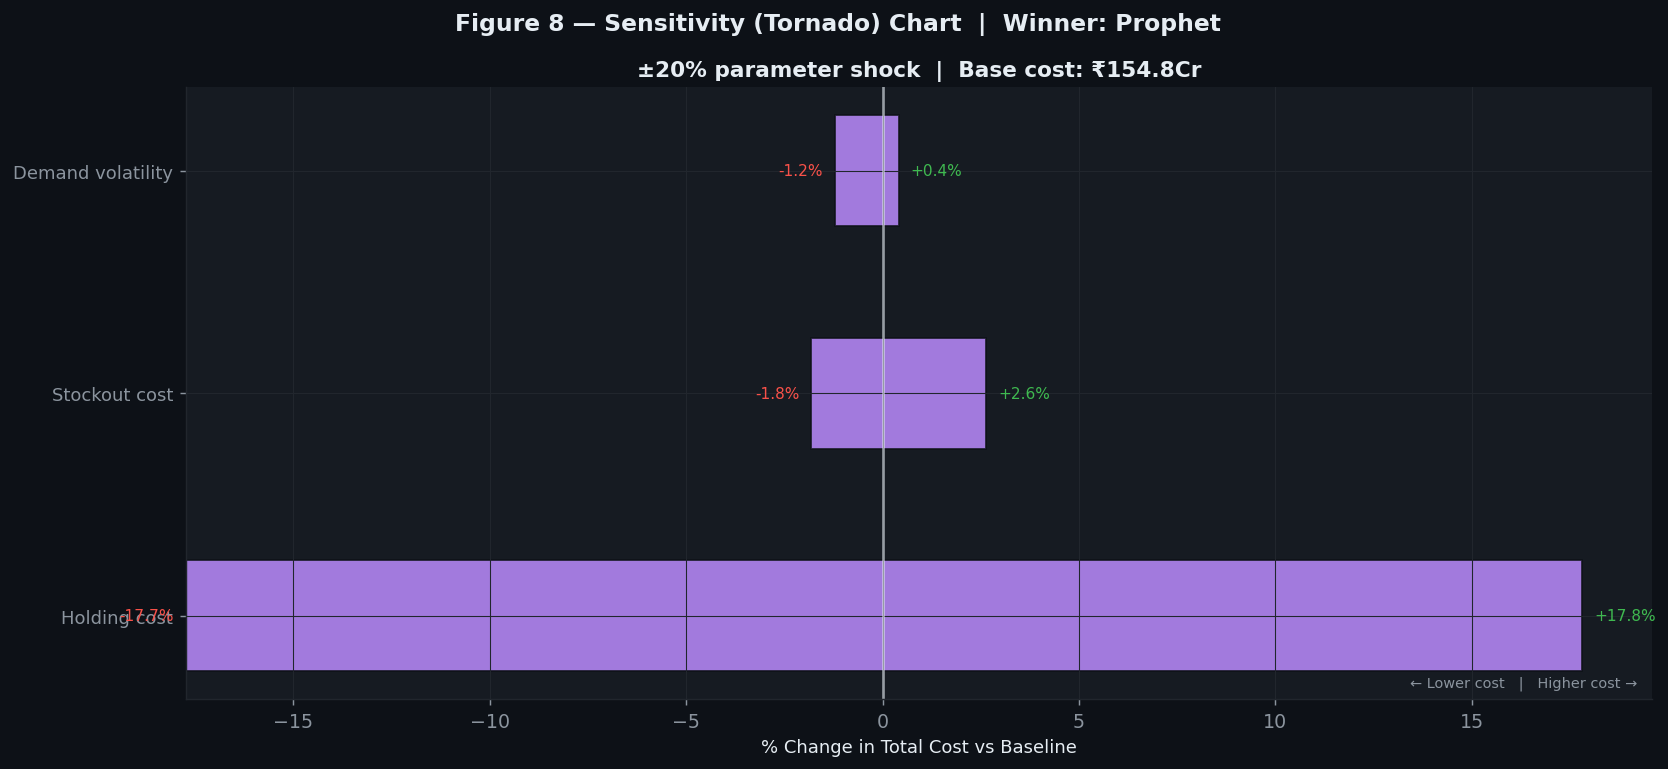

In [34]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 8 — Sensitivity / Tornado Chart (FINAL CLEAN)
# ────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)

print("Running sensitivity analysis …")

# winner setup
mname_s = winner_name
mu_s    = {"Prophet":mu_p_agg_full,"XGBoost":mu_x_agg_full,"Rolling":mu_r_agg_full}[mname_s]
sig_s   = {"Prophet":sigma_p_agg,  "XGBoost":sigma_x_agg,  "Rolling":sigma_r_agg}[mname_s]
b_s     = bests[mname_s]
base_cost = all_res[mname_s]["total_cost"]

# fallback safety (if globals missing)
N_local        = len(store_ids)
shares_local   = np.array([store_shares[s] for s in store_ids])
sigmas_local   = np.array([store_sigma_idio[s] for s in store_ids])


def perturb_sim(delta_dict, n_sims=60):

    HC_s = CFG.holding_cost_store * delta_dict.get("HC",1.0)
    HC_w = CFG.holding_cost_wh    * delta_dict.get("HC",1.0)
    SC   = CFG.stockout_cost      * delta_dict.get("SC",1.0)
    sig  = sig_s                  * delta_dict.get("sigma",1.0)

    T_full = len(mu_s)
    mu_arr = np.asarray(mu_s)

    buf    = T_full + max(CFG.l_wh, CFG.l_store) + 2
    costs  = []

    for sim in range(n_sims):
        wh_pipe = np.zeros(buf)
        st_pipe = np.zeros((N_local, buf))

        wh_inv  = max(b_s["s_wh"] + b_s["Q_wh"]/2.,
                      avg_demand_agg * CFG.l_wh * 1.5)

        st_inv  = b_s["s_store"] + np.random.uniform(0., b_s["Q_store"], N_local)

        hc = sc = oc = 0.

        for t in range(T_full):
            m = t >= CFG.warm_up_weeks

            # arrivals
            wh_inv += wh_pipe[t]; wh_pipe[t]=0.
            wh_inv  = min(wh_inv, WH_CAPACITY)

            st_inv += st_pipe[:,t]; st_pipe[:,t]=0.

            # demand
            agg_d  = max(0., mu_arr[t] + np.random.normal(0., sig))
            demand = np.maximum(0., agg_d * shares_local +
                                     np.random.normal(0., sigmas_local))

            sold   = np.minimum(st_inv, demand)
            lost_v = demand - sold
            st_inv -= sold

            if m:
                sc += lost_v.sum() * SC
                hc += st_inv.sum() * HC_s

            # store reorder
            ip_s = st_inv + st_pipe[:, t+1:t+CFG.l_store+1].sum(1)
            ri   = np.where(ip_s <= b_s["s_store"])[0]

            if len(ri) > 0:
                if m:
                    oc += len(ri) * CFG.order_cost_store

                f = min(len(ri) * b_s["Q_store"], wh_inv)
                wh_inv -= f

                st_pipe[ri, t+CFG.l_store] += f / len(ri)

            # warehouse cost
            if m:
                hc += wh_inv * HC_w

            # warehouse reorder
            ip_wh = wh_inv + wh_pipe[t+1:t+CFG.l_wh+1].sum()

            if ip_wh <= b_s["s_wh"]:
                lt2 = max(1, int(round(np.random.normal(CFG.l_wh, CFG.l_wh_std))))
                wh_pipe[min(t+lt2, buf-1)] += b_s["Q_wh"]

                if m:
                    oc += CFG.order_cost_wh

        costs.append(hc + sc + oc)

    return float(np.mean(costs))


# sensitivity parameters
params = [
    ("Holding cost",      {"HC":1.2},      {"HC":0.8}),
    ("Stockout cost",     {"SC":1.2},      {"SC":0.8}),
    ("Demand volatility", {"sigma":1.2},   {"sigma":0.8}),
]

results_sens = []

for label, hi_d, lo_d in params:
    try:
        c_hi = perturb_sim(hi_d)
        c_lo = perturb_sim(lo_d)

        results_sens.append((
            label,
            (c_lo - base_cost)/base_cost * 100,
            (c_hi - base_cost)/base_cost * 100
        ))
    except Exception as e:
        print(f"⚠️ Skipped {label}: {e}")

# sort by impact
results_sens.sort(key=lambda x: abs(x[2] - x[1]), reverse=True)


# ── plotting ──
fig, ax = plt.subplots(figsize=(13, 6), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

fig.suptitle(f"Figure 8 — Sensitivity (Tornado) Chart  |  Winner: {mname_s}",
             fontsize=13, fontweight="bold", color=TEXT_COL)

ys = np.arange(len(results_sens))

for i, (label, pct_lo, pct_hi) in enumerate(results_sens):
    left  = min(pct_lo, pct_hi)
    right = max(pct_lo, pct_hi)

    ax.barh(i, right-left, left=left,
            color=PALETTE["WH"], alpha=0.85,
            height=0.5, edgecolor=DARK_BG)

    ax.text(left - 0.3, i, f"{pct_lo:+.1f}%",
            ha="right", va="center", fontsize=8.5, color=RED)

    ax.text(right + 0.3, i, f"{pct_hi:+.1f}%",
            ha="left", va="center", fontsize=8.5, color=GREEN)


ax.set_yticks(ys)
ax.set_yticklabels([r[0] for r in results_sens], fontsize=10)

ax.axvline(0, color=TEXT_COL, lw=1.5, alpha=0.6)

ax.set_xlabel("% Change in Total Cost vs Baseline")
ax.set_title(f"±20% parameter shock  |  Base cost: ₹{base_cost/1e7:.1f}Cr")

ax.spines["bottom"].set_color(GRID_COL)
ax.spines["left"].set_color(GRID_COL)

ax.text(0.99, 0.02,
        "← Lower cost   |   Higher cost →",
        transform=ax.transAxes,
        ha="right", fontsize=8, color=MUTED)

plt.tight_layout()

plt.savefig("outputs/fig8_tornado.png",
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)

plt.show()

### Figure 9 · Store-Level Demand Heatmap

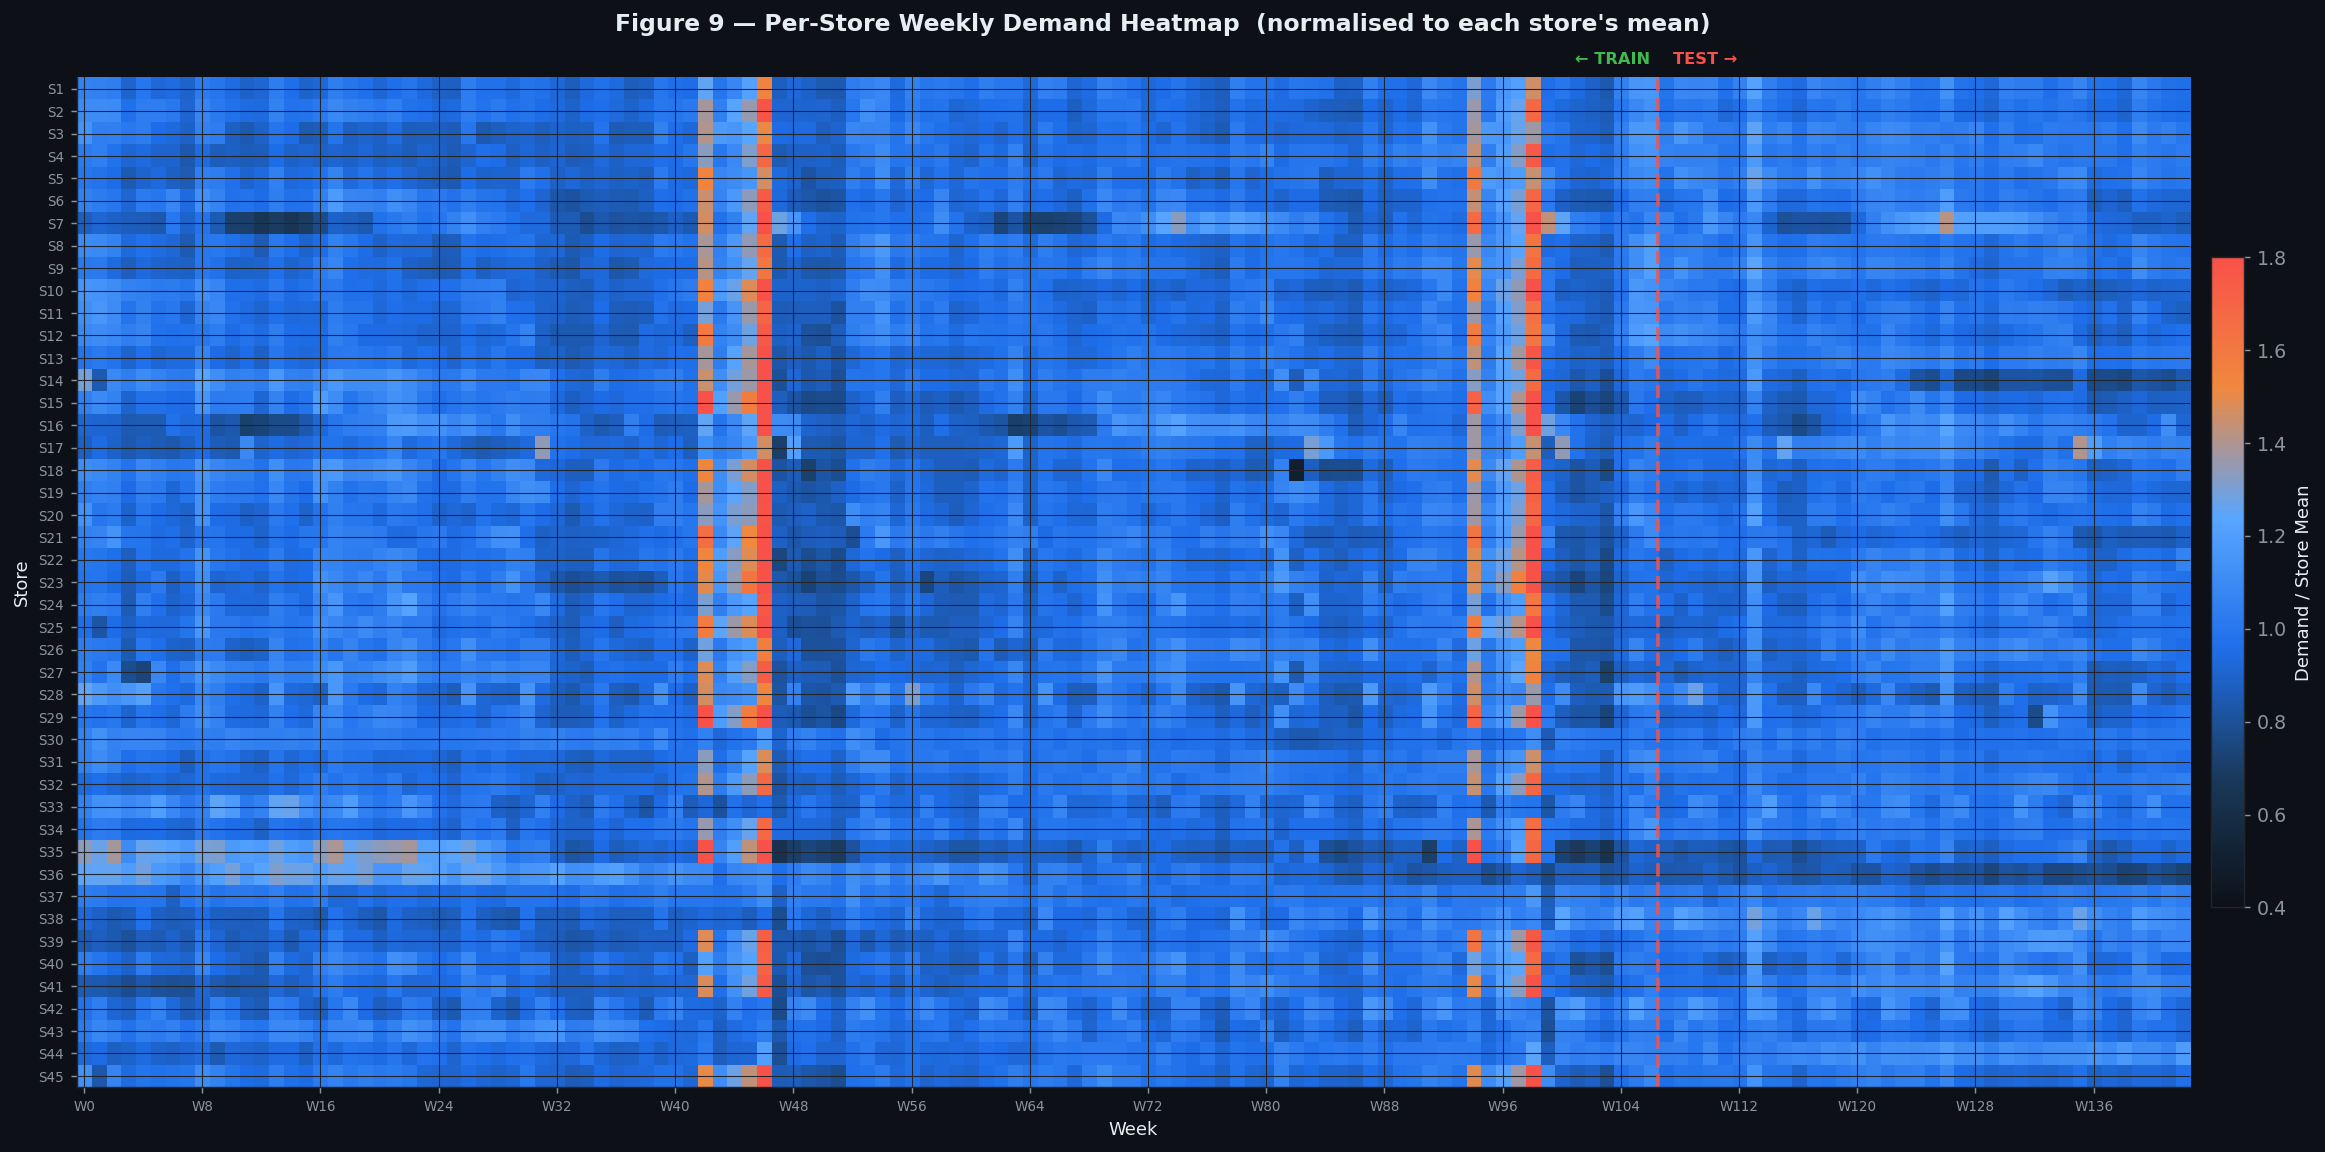

In [35]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 9 — Store-Level Demand Heatmap (weekly sales by store)
# ────────────────────────────────────────────────────────────────────────
pivot = data.pivot_table(index="Store", columns="Date",
                          values="Weekly_Sales", aggfunc="sum")
pivot.columns = range(len(pivot.columns))

# normalise per-store so colour shows within-store variation
pivot_norm = pivot.div(pivot.mean(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(18, 9), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
fig.suptitle("Figure 9 — Per-Store Weekly Demand Heatmap  (normalised to each store's mean)",
             fontsize=13, fontweight="bold", color=TEXT_COL)

cmap = LinearSegmentedColormap.from_list(
    "demand", ["#0D1117", "#1A3A5C", "#1F6FEB", "#58A6FF", "#F0883E", "#F85149"])

im = ax.imshow(pivot_norm.values, aspect="auto", cmap=cmap,
               interpolation="nearest", vmin=0.4, vmax=1.8)

# train/test divider
train_end = len(train_dates)
ax.axvline(train_end - 0.5, color=RED, lw=2, ls="--", alpha=0.85)
ax.text(train_end+0.5, -1.1, "TEST →", color=RED, fontsize=9, fontweight="bold")
ax.text(train_end-1,   -1.1, "← TRAIN", color=GREEN, fontsize=9,
        ha="right", fontweight="bold")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"S{sid}" for sid in pivot.index], fontsize=7.5)
# x ticks: every 8 weeks
x_ticks = range(0, len(pivot.columns), 8)
ax.set_xticks(list(x_ticks))
ax.set_xticklabels([f"W{w}" for w in x_ticks], fontsize=7.5)
ax.set_xlabel("Week", color=TEXT_COL)
ax.set_ylabel("Store", color=TEXT_COL)

cbar = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cbar.set_label("Demand / Store Mean", color=TEXT_COL)
cbar.ax.yaxis.set_tick_params(color=MUTED)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=MUTED)

plt.tight_layout()
plt.savefig("outputs/fig9_store_heatmap.png")
plt.show()


### Figure 10 · XGBoost Feature Importance

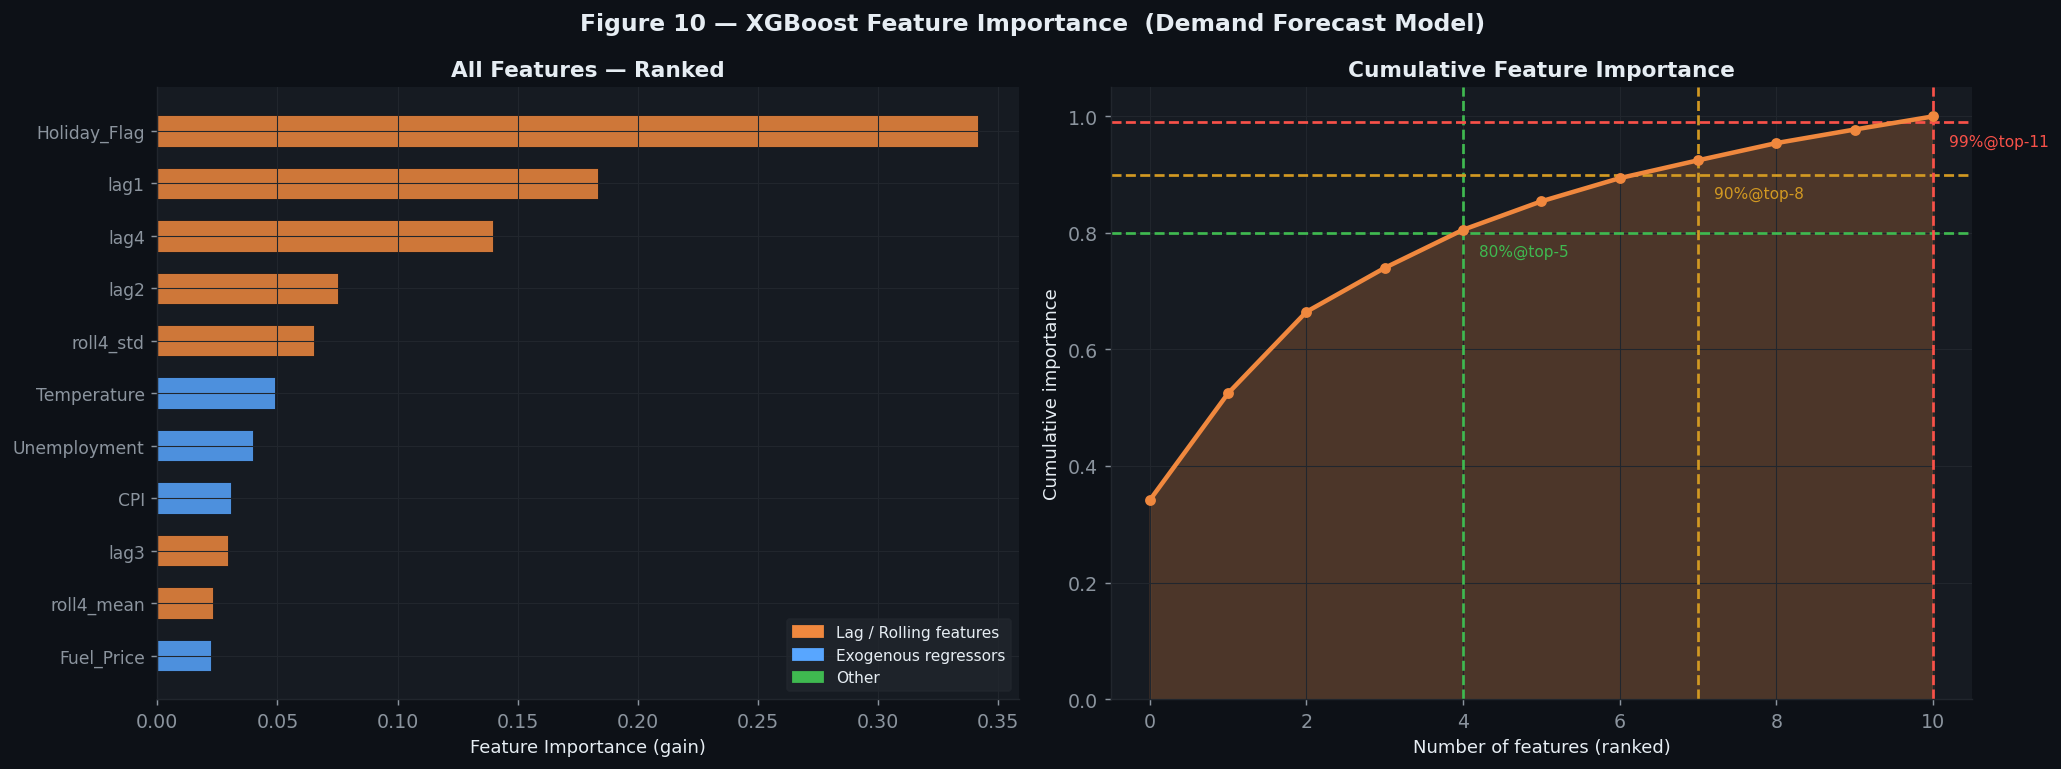

In [36]:
# ────────────────────────────────────────────────────────────────────────
# FIGURE 10 — XGBoost Feature Importance
# ────────────────────────────────────────────────────────────────────────
importances = xgb_agg.feature_importances_
feat_names  = feat_agg
sorted_idx  = np.argsort(importances)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=DARK_BG)
fig.suptitle("Figure 10 — XGBoost Feature Importance  (Demand Forecast Model)",
             fontsize=13, fontweight="bold", color=TEXT_COL)

# Panel A — horizontal bar
ax = axes[0]
ax.set_facecolor(CARD_BG)
ys   = np.arange(len(feat_names))
cols = [PALETTE["XGBoost"] if "lag" in f or "roll" in f
        else ACCENT if f in exog_cols else GREEN
        for f in [feat_names[i] for i in sorted_idx]]
bars = ax.barh(ys, importances[sorted_idx], color=cols, alpha=0.85, height=0.6,
               edgecolor=DARK_BG, linewidth=0.5)
ax.set_yticks(ys)
ax.set_yticklabels([feat_names[i] for i in sorted_idx], fontsize=9.5)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("All Features — Ranked")
ax.spines["bottom"].set_color(GRID_COL); ax.spines["left"].set_color(GRID_COL)
patches = [
    mpatches.Patch(color=PALETTE["XGBoost"], label="Lag / Rolling features"),
    mpatches.Patch(color=ACCENT,             label="Exogenous regressors"),
    mpatches.Patch(color=GREEN,              label="Other"),
]
ax.legend(handles=patches, fontsize=8.5, loc="lower right")

# Panel B — cumulative importance
ax = axes[1]
ax.set_facecolor(CARD_BG)
sorted_desc = np.argsort(importances)[::-1]
cumul = np.cumsum(importances[sorted_desc])
ax.fill_between(range(len(cumul)), cumul, alpha=0.25, color=PALETTE["XGBoost"])
ax.plot(range(len(cumul)), cumul, color=PALETTE["XGBoost"], lw=2.5, marker="o",
        markersize=5, zorder=4)
for thresh, color in [(0.8, GREEN),(0.9, ORANGE),(0.99, RED)]:
    idx_t = int(np.searchsorted(cumul, thresh))
    ax.axvline(idx_t, color=color, ls="--", lw=1.5)
    ax.axhline(thresh, color=color, ls="--", lw=1.5)
    ax.text(idx_t+0.2, thresh-0.04, f"{thresh:.0%}@top-{idx_t+1}",
            color=color, fontsize=8.5)
ax.set_xlabel("Number of features (ranked)")
ax.set_ylabel("Cumulative importance")
ax.set_title("Cumulative Feature Importance")
ax.set_ylim(0, 1.05)
ax.spines["bottom"].set_color(GRID_COL); ax.spines["left"].set_color(GRID_COL)

fig.tight_layout()
plt.savefig("fig10_feature_importance.png",
            dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

## 10 · Backtest Validation

In [37]:
b = bests[winner_name]; r = all_res[winner_name]

sigma_test = float(test_global["Weekly_Sales"].std())
ratio_agg  = sigma_aggregate / sigma_test

raw_data = pd.read_csv(CFG.data_path)
raw_data["Date"] = pd.to_datetime(raw_data["Date"], format="%d-%m-%Y")
avg_weekly_rev   = float(raw_data[raw_data["Date"].isin(test_dates)]
                         .groupby("Store")["Weekly_Sales"].mean().mean()) * CFG.inr_per_usd
annual_rev       = avg_weekly_rev * 52
avg_st_inv_units = b["s_store"] + b["Q_store"]/2.
avg_st_inv_inr   = avg_st_inv_units * CFG.unit_price_inr
inv_weeks_rev    = avg_st_inv_inr / avg_weekly_rev

sigma_eff = float(np.mean([
    np.sqrt((store_shares[sid]*sigma_aggregate)**2 + store_sigma_idio[sid]**2)
    for sid in store_ids]))
mu_l  = (avg_demand_agg/n_stores)*CFG.l_store
sig_l = sigma_eff*np.sqrt(CFG.l_store)
z_f   = (b["s_store"]-mu_l)/sig_l if sig_l>0 else 10.
phi_z = sp_norm.pdf(z_f); Phi_z = sp_norm.cdf(z_f)
G_z   = phi_z - z_f*(1-Phi_z)
theor_sl = float(np.clip(1-(sig_l/b["Q_store"])*G_z,0,1))

hc_pct = r["hc"]/r["total_cost"]; sc_pct = r["sc"]/r["total_cost"]; oc_pct = r["oc"]/r["total_cost"]
ann_cost_pct = (r["total_cost"]/n_stores)*(52/len(test_dates))/annual_rev*100

print(f"{'═'*68}")
print(f"BACKTEST VALIDATION — {winner_name}")
print(f"{'═'*68}")
checks = [
    ("A — σ ratio (expect 3.0)",    f"{ratio_agg:.2f}×",   abs(ratio_agg-3.)<0.05),
    ("B — Inventory weeks on hand", f"{inv_weeks_rev:.1f}w", 1.5<=inv_weeks_rev<=8),
    ("C — Theoretical vs MC SL",   f"Δ={abs(theor_sl-r['fill_rate']):.1%}",
                                    abs(theor_sl-r["fill_rate"])<0.05),
    ("D — HC% (40–70%)",            f"{hc_pct:.0%}",       0.40<=hc_pct<=0.70),
    ("D — SC% (5–25%)",             f"{sc_pct:.0%}",       0.05<=sc_pct<=0.25),
    ("D — OC% (1–5%)",              f"{oc_pct:.0%}",       0.01<=oc_pct<=0.05),
    ("D — Annual inv/rev% (5–15%)", f"{ann_cost_pct:.1f}%",5<=ann_cost_pct<=15),
]
for label, val, ok in checks:
    icon = "OK" if ok else "->>WARNING<<- "
    print(f"  {icon}  {label:<35} {val}")

════════════════════════════════════════════════════════════════════
BACKTEST VALIDATION — Prophet
════════════════════════════════════════════════════════════════════
  OK  A — σ ratio (expect 3.0)            3.00×
  OK  B — Inventory weeks on hand         2.0w
  OK  C — Theoretical vs MC SL            Δ=0.4%
  ->>WARNING<<-   D — HC% (40–70%)                    87%
  OK  D — SC% (5–25%)                     12%
  OK  D — OC% (1–5%)                      1%
  ->>WARNING<<-   D — Annual inv/rev% (5–15%)         1.1%


## 11 · Final Summary

In [38]:
r = all_res[winner_name]; b = bests[winner_name]
saving     = se_cost - r["total_cost"]
saving_pct = saving / se_cost * 100

print(f"{'═'*68}")
print(f"  FINAL INVENTORY OPTIMISATION SUMMARY")
print(f"{'═'*68}")
print(f"  Winner model      : {winner_name}")
print(f"  WH reorder point  : {b['s_wh']:>15,} units  ({b['s_wh']/avg_demand_agg:.1f}wk agg)")
print(f"  WH order qty      : {b['Q_wh']:>15,} units  ({b['Q_wh']/avg_demand_agg:.1f}wk agg)")
print(f"  Store s* (per)    : {b['s_store']:>15,} units")
print(f"  Store Q* (per)    : {b['Q_store']:>15,} units")
print(f"  Total cost        : ₹{r['total_cost']:>15,.0f}")
print(f"  Service level     :  {r['fill_rate']:>14.1%}")
print(f"")
print(f"  vs Single-echelon (45 stores × L={CFG.l_total}wk):")
print(f"    SE cost          ₹{se_cost:,.0f}  SL {se_sl:.1%}")
print(f"    Two-echelon saves ₹{saving:,.0f}  ({saving_pct:.1f}%)")
print(f"")
print(f"  Risk pooling saving: {pooling_saving_pct:.1f}% less safety stock")
print(f"  SS cost saving/week: ₹{pooling_saving*CFG.holding_cost_store:,.0f}")
print(f"")
print(f"  Figures saved to /mnt/user-data/outputs/")
print(f"  fig0_dashboard.png        — Executive KPI cards")
print(f"  fig1_forecast.png         — Demand forecast vs actuals")
print(f"  fig2_architecture.png     — System architecture")
print(f"  fig3_risk_pooling.png     — Risk pooling deep dive")
print(f"  fig4_model_comparison.png — Cost / SL / breakdown")
print(f"  fig5_wh_trajectory.png    — WH inventory trajectories")
print(f"  fig6_monte_carlo.png      — MC cost distributions")
print(f"  fig7_pareto.png           — Cost-SL Pareto frontier")
print(f"  fig8_tornado.png          — Sensitivity tornado chart")
print(f"  fig9_store_heatmap.png    — Store demand heatmap")
print(f"  fig10_feature_importance.png — XGBoost features")

════════════════════════════════════════════════════════════════════
  FINAL INVENTORY OPTIMISATION SUMMARY
════════════════════════════════════════════════════════════════════
  Winner model      : Prophet
  WH reorder point  :       6,020,780 units  (3.9wk agg)
  WH order qty      :       2,340,203 units  (1.5wk agg)
  Store s* (per)    :          34,669 units
  Store Q* (per)    :          69,339 units
  Total cost        : ₹  1,547,610,194
  Service level     :           97.5%

  vs Single-echelon (45 stores × L=4wk):
    SE cost          ₹3,163,549,776  SL 97.1%
    Two-echelon saves ₹1,615,939,583  (51.1%)

  Risk pooling saving: 54.1% less safety stock
  SS cost saving/week: ₹8,102,715

  Figures saved to /mnt/user-data/outputs/
  fig0_dashboard.png        — Executive KPI cards
  fig1_forecast.png         — Demand forecast vs actuals
  fig2_architecture.png     — System architecture
  fig3_risk_pooling.png     — Risk pooling deep dive
  fig4_model_comparison.png — Cost / SL / br